<a href="https://colab.research.google.com/github/mintyougurt/OM-of-offshore-wind-turbine/blob/main/OM_based_on_DE_algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Obtain data**

In [ ]:
#connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.stats import skew, kurtosis
import matplotlib.dates as mdates
import math
import pickle
import seaborn as sns
import gym

In [ ]:
#read scada data
dfT01= pd.read_csv('/content/drive/MyDrive/j2/dfT01.csv', index_col=None)
dfT11= pd.read_csv('/content/drive/MyDrive/j2/dfT011.csv', index_col=None)
dfT06= pd.read_csv('/content/drive/MyDrive/j2/dfT06.csv', index_col=None)
dfT07= pd.read_csv('/content/drive/MyDrive/j2/dfT07.csv', index_col=None)

#sort by Timestamp
def preprocess_dataframe(df):
    df["Timestamp"] = pd.to_datetime(df["Timestamp"]).dt.strftime('%Y-%m-%d %H:%M:%S')
    df = df.sort_values(by='Timestamp', ascending=True).reset_index(drop=True)
    df['Fault'] = 0
    return df

# Apply the function
dfT01 = preprocess_dataframe(dfT01)
dfT11 = preprocess_dataframe(dfT11)
dfT06 = preprocess_dataframe(dfT06)
dfT07 = preprocess_dataframe(dfT07)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
norelec= pd.read_csv('/content/drive/MyDrive/j2/norelec.csv', index_col=0) # electricity price unit EUR/MWh

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
#failure logs: note that scada data of T09 is lacked
#Timestamp- original time, Timestamp_r-to 10 min interval
f = pd.read_csv('/content/drive/MyDrive/j2/failures.csv')
f['Timestamp_r'] = pd.to_datetime(f['Timestamp']).dt.floor('10T').dt.strftime('%Y-%m-%d %H:%M:%S')
f["Timestamp_r"] = pd.to_datetime(f["Timestamp_r"]).dt.strftime('%Y-%m-%d %H:%M:%S')
f.sort_values(by='Timestamp', ascending=True).reset_index(drop=True)
#count the number failures for each turbine
fault_count_by_turbine = f.groupby('Turbine_ID').size()
print(fault_count_by_turbine)
f

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Turbine_ID
T01    2
T06    8
T07    7
T11    4
dtype: int64


,Turbine_ID,Component,Timestamp,Remarks,Timestamp_r
0,T11,GENERATOR,2016-03-03 19:00:00+00:00,Electric circuit error in generator,2016-03-03 19:00:00
1,T06,HYDRAULIC_GROUP,2016-04-04 18:53:00+00:00,Error in pitch regulation,2016-04-04 18:50:00
2,T07,GENERATOR_BEARING,2016-04-30 12:40:00+00:00,High temperature in generator bearing (replace...,2016-04-30 12:40:00
3,T07,TRANSFORMER,2016-07-10 03:46:00+00:00,High temperature transformer,2016-07-10 03:40:00
4,T06,GENERATOR,2016-07-11 19:48:00+00:00,Generator replaced,2016-07-11 19:40:00
5,T01,GEARBOX,2016-07-18 02:10:00+00:00,Gearbox pump damaged,2016-07-18 02:10:00
6,T06,GENERATOR,2016-07-24 17:01:00+00:00,Generator temperature sensor failure,2016-07-24 17:00:00
7,T07,TRANSFORMER,2016-08-23 02:21:00+00:00,High temperature transformer. Transformer refr...,2016-08-23 02:20:00
8,T06,GENERATOR,2016-09-04 08:08:00+00:00,High temperature generator error,2016-09-04 08:00:00
9,T06,GENERATOR,2016-10-02 17:08:00+00:00,Refrigeration system and temperature sensors i...,2016-10-02 17:00:00


In [ ]:
#check if failure time exists in Timestamp (10-min interval)
for _, row in f.iterrows():
    turbine_id = row['Turbine_ID']
    timestamp = row['Timestamp_r']
    if turbine_id == 'T01':
        dfT01.loc[(dfT01['Turbine_ID'] == turbine_id) & (dfT01['Timestamp'] == timestamp), 'Fault'] = 1
    elif turbine_id == 'T07':
        dfT07.loc[(dfT07['Turbine_ID'] == turbine_id) & (dfT07['Timestamp'] == timestamp), 'Fault'] = 1
    elif turbine_id == 'T06':
        dfT06.loc[(dfT06['Turbine_ID'] == turbine_id) & (dfT06['Timestamp'] == timestamp), 'Fault'] = 1
    elif turbine_id == 'T11':
        dfT11.loc[(dfT11['Turbine_ID'] == turbine_id) & (dfT11['Timestamp'] == timestamp), 'Fault'] = 1

print('T11 lacks', 4-sum(dfT11['Fault']))
print('T07 lacks',7-sum(dfT07['Fault']))
print('T06 lacks',8-sum(dfT06['Fault']))
print('T01 lacks',2-sum(dfT01['Fault']))

turbine_dfs = [dfT11, dfT06, dfT07, dfT01]
merged_turbine_df = pd.concat(turbine_dfs, ignore_index=True)
faulty_turbine = merged_turbine_df[merged_turbine_df['Fault'] != 0]
matchingf = f[f['Turbine_ID'].isin(faulty_turbine['Turbine_ID']) & f['Timestamp_r'].isin(faulty_turbine['Timestamp'])]

fault_count_by_turbine = matchingf.groupby('Turbine_ID').size()
print(fault_count_by_turbine)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


T11 lacks 1
T07 lacks 0
T06 lacks 1
T01 lacks 0
Turbine_ID
T01    2
T06    7
T07    7
T11    3
dtype: int64


In [ ]:
#check lost failure time for T11 and T06
merged_df = pd.merge(f, matchingf, on=['Timestamp_r'], how='left', indicator=True)
result_df = merged_df.query('_merge == "left_only"').drop('_merge', axis=1)
result_df = result_df[result_df['Turbine_ID_x'].isin(["T11", "T06"])]
result_df= result_df.dropna(axis=1, how='any', inplace=False)
result_df

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,Turbine_ID_x,Component_x,Timestamp_x,Remarks_x,Timestamp_r
0,T11,GENERATOR,2016-03-03 19:00:00+00:00,Electric circuit error in generator,2016-03-03 19:00:00
4,T06,GENERATOR,2016-07-11 19:48:00+00:00,Generator replaced,2016-07-11 19:40:00


In [ ]:
# Find the closest and preceding timestamps in df and mark 'Fault' as 1
def mark_faults(df, given_timestamps):
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    for given_timestamp in given_timestamps:
        closest_timestamp = df[df['Timestamp'] <= given_timestamp]['Timestamp'].max()
        df.loc[df['Timestamp'] == closest_timestamp, 'Fault'] = 1
    return df

# Given timestamps from result_df
given_timestamps_011 = ['2016-03-03 19:00:00']
given_timestamps_06 = ['2016-07-11 19:48:00']

# Mark faults for dfT011
dfT11 = mark_faults(dfT11.copy(), given_timestamps_011)
print(sum(dfT11['Fault']))

# Mark faults for dfT06
dfT06 = mark_faults(dfT06.copy(), given_timestamps_06)
print(sum(dfT06['Fault']))

4
8


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
#Get average temperature data
def process_temperature_data(df):
    # Keep average temp data and create a copy
    df_filtered = df.filter(regex='Temp.*Avg|Avg.*Temp').copy()

    # Subtract 'Amb_Temp_Avg' from each relevant column and drop it
    df_filtered.iloc[:, 1:] -= df['Amb_Temp_Avg'].values[:, None]
    df_filtered = df_filtered.drop('Amb_Temp_Avg', axis=1, errors='ignore')

    # Include 'Timestamp' and 'Fault' columns if they exist
    df_filtered['Timestamp'] = df.get('Timestamp', None)
    df_filtered['Fault'] = df.get('Fault', None)
    return df_filtered

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
dfT01s_temp = process_temperature_data(dfT01)
dfT11s_temp = process_temperature_data(dfT11)
dfT07s_temp = process_temperature_data(dfT07)
dfT06s_temp = process_temperature_data(dfT06)

print(dfT06s_temp.shape)
print(dfT01s_temp.shape)
print(dfT07s_temp.shape)
print(dfT11s_temp.shape)

(102921, 26)
(104683, 26)
(104739, 26)
(104798, 26)


# **2. NBM autoencoder from T01**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from keras.layers import Input, Dense, BatchNormalization
from keras.models import Model,load_model
from keras.optimizers import Adam
from keras.initializers import he_normal
from keras import backend as K
import tensorflow as tf

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
initializer = he_normal(seed=98)
scaler = StandardScaler()
def build_autoencoder(input_dim, encoding_dims, num_layers):
    input_layer = Input(shape=(input_dim,))
    encoded = input_layer
    # Encoding layers
    for i in range(num_layers):
        encoded = Dense(encoding_dims[i], activation='relu', input_dim=input_dim, kernel_initializer=initializer)(encoded)
    decoded = encoded  # Initialize decoded
    # Decoding layers
    for i in range(num_layers - 1, -1, -1):
        decoded = Dense(encoding_dims[i], activation='relu', input_dim=input_dim, kernel_initializer=initializer)(decoded)
    decoded = Dense(input_dim, activation='linear')(decoded)
    autoencoder = Model(input_layer, decoded)
    return autoencoder
def root_mean_squared_error(y_true, y_pred):
    return K.sqrt(K.mean(K.square(y_pred - y_true)))

physical_devices = tf.config.list_physical_devices('GPU')
print("Available GPUs:", physical_devices)

Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
df=dfT01s_temp
temperature_data = df.iloc[:, :24].values
# Calculate the split indices
train_index = int(0.1 * len(temperature_data))
print("split train and val:",train_index)
val_index = int(0.15 * len(temperature_data))
print("split val and test:",val_index)
print(df.iloc[0]["Timestamp"])
print(df.iloc[train_index]["Timestamp"])
print(df.iloc[val_index]["Timestamp"])

split train and val: 10468
split val and test: 15702
2016-01-01 00:00:00
2016-03-13 17:20:00
2016-04-19 02:40:00


In [ ]:
#split data
temperature_data_normalized = scaler.fit_transform(temperature_data)
X_train =temperature_data_normalized[:train_index, :]
X_val =temperature_data_normalized[train_index:val_index, :]
X_test = temperature_data_normalized[val_index:, :]

In [ ]:
input_dim = 24
encoding_dims = [18]
num_layers = len(encoding_dims)
autoencoder = build_autoencoder(input_dim, encoding_dims, num_layers)
optimizer = Adam(learning_rate=0.001)
autoencoder.compile(optimizer=optimizer, loss=root_mean_squared_error)  # rmse

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
autoencoder.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 24)]              0         
                                                                 
 dense (Dense)               (None, 18)                450       
                                                                 
 dense_1 (Dense)             (None, 18)                342       
                                                                 
 dense_2 (Dense)             (None, 24)                456       
                                                                 
Total params: 1248 (4.88 KB)
Trainable params: 1248 (4.88 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


# Train process (jump)


In [ ]:
start_time = time.time()
with tf.device('/GPU:0'):
    history = autoencoder.fit(
        X_train, X_train,
        epochs=100,
        batch_size=64,
        shuffle=True,
        validation_data=(X_val, X_val))

end_time = time.time()
training_time = end_time - start_time
print(f"Training time: {training_time} seconds")

Epoch 1/100
164/164 [==============================] - 4s 6ms/step - loss: 0.6536 - val_loss: 0.4202
Epoch 2/100
164/164 [==============================] - 0s 3ms/step - loss: 0.3242 - val_loss: 0.2724
Epoch 3/100
164/164 [==============================] - 0s 3ms/step - loss: 0.2371 - val_loss: 0.2146
Epoch 4/100
164/164 [==============================] - 0s 3ms/step - loss: 0.1973 - val_loss: 0.1924
Epoch 5/100
164/164 [==============================] - 0s 3ms/step - loss: 0.1788 - val_loss: 0.1782
Epoch 6/100
164/164 [==============================] - 0s 3ms/step - loss: 0.1654 - val_loss: 0.1681
Epoch 7/100
164/164 [==============================] - 0s 3ms/step - loss: 0.1542 - val_loss: 0.1602
Epoch 8/100
164/164 [==============================] - 1s 3ms/step - loss: 0.1457 - val_loss: 0.1531
Epoch 9/100
164/164 [==============================] - 1s 3ms/step - loss: 0.1387 - val_loss: 0.1459
Epoch 10/100
164/164 [==============================] - 1s 3ms/step - loss: 0.1314 - val_lo

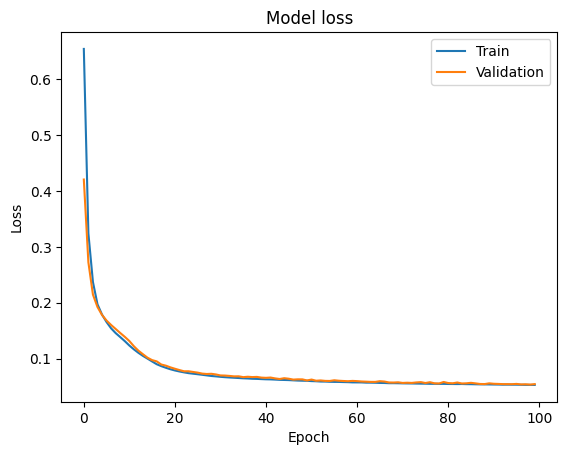

In [ ]:
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

In [ ]:
# save autoencoder
autoencoder.save('/content/drive/MyDrive/j2/autoencoder_model2.h5')

# save weights of autoencoder
autoencoder.save_weights('/content/drive/MyDrive/j2/autoencoder_weights2.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


# Apply model (jump)

In [ ]:
autoencoder_model=load_model('/content/drive/MyDrive/j2/autoencoder_model2.h5',custom_objects={'root_mean_squared_error': root_mean_squared_error})

In [ ]:
def detect_anomalies(df, autoencoder_model):
    scaler = StandardScaler()
    temperature_data = df.iloc[:, :24].values #only temperature data
    temperature_data_normalized = scaler.fit_transform(temperature_data)

    reconstructed_data = autoencoder_model.predict(temperature_data_normalized)
    reconstruction_error = np.mean(np.square(temperature_data_normalized - reconstructed_data), axis=1)
    df['ReconstructionError'] = reconstruction_error
    return df

# apply to other turbines and periods
df_result6 = detect_anomalies(dfT06s_temp, autoencoder_model)
df_result7 = detect_anomalies(dfT07s_temp, autoencoder_model)
df_result11 = detect_anomalies(dfT11s_temp, autoencoder_model)
df_result1 = detect_anomalies(dfT01s_temp, autoencoder_model)

3272/3272 [==============================] - 4s 1ms/step


In [ ]:
#df_result1.to_csv('/content/drive/MyDrive/j2/df_result1.csv')
#df_result6.to_csv('/content/drive/MyDrive/j2/df_result6.csv')
#df_result7.to_csv('/content/drive/MyDrive/j2/df_result7.csv')
#df_result11.to_csv('/content/drive/MyDrive/j2/df_result11.csv')

# **3. Plots of Anomaly detection (jump)**

In [ ]:
#read results if you have saved them
df_result1=pd.read_csv('/content/drive/MyDrive/j2/df_result1.csv', index_col=0)
df_result6=pd.read_csv('/content/drive/MyDrive/j2/df_result6.csv', index_col=0)
df_result7=pd.read_csv('/content/drive/MyDrive/j2/df_result7.csv', index_col=0)
df_result11=pd.read_csv('/content/drive/MyDrive/j2/df_result11.csv', index_col=0)

df_result1 = preprocess_dataframe(df_result1)
df_result6 = preprocess_dataframe(df_result6)
df_result7 = preprocess_dataframe(df_result7)
df_result11 = preprocess_dataframe(df_result11)

In [ ]:
def detect_change_points(data, df, dfT, threshold, texts, window_size=10, plot=True, pdf_filename=None):
    diff = np.diff(data)
    rolling_std = np.std(np.lib.stride_tricks.sliding_window_view(diff, window_shape=(window_size,)), axis=1)
    change_point_indices = np.where(rolling_std > threshold)[0]


    if plot:
        plt.figure(figsize=(10, 6))
        plt.plot(rolling_std, label ='Normal',color='blue')
        tick_indices = np.linspace(0, len(rolling_std)-1, 6, dtype=int)
        selected_timestamps = pd.to_datetime(dfT['Timestamp']).iloc[tick_indices]
        formatted_timestamps = selected_timestamps.dt.to_period('M').astype(str)
        plt.xticks(tick_indices,  formatted_timestamps, rotation=0, ha='center')
        plt.axhline(y=0, color='green', linestyle='--')

        faulty_index = list(dfT[dfT['Fault'] != 0].index)
        print(faulty_index)
        for i in range(len(faulty_index)):
          idx = faulty_index[i]
          plt.axvline(x=idx, color='red', linestyle='--')
          plt.annotate(texts[i],
                 xy=(idx, plt.ylim()[1]*0.8),
                 xytext=(idx-5000, plt.ylim()[1]*0.8),
                 color='purple',
                 ha='right',
                 va='center',
                 bbox=dict(boxstyle='round,pad=0.3', edgecolor='purple', facecolor='white',alpha=0.7),
                 arrowprops=dict(arrowstyle='->', color='purple'))

        plt.plot(change_point_indices, rolling_std [change_point_indices], 'ro', label='Abnormal')

        plt.legend()
        plt.ylabel('Anomaly Indicator')
        plt.xlabel('Date')
        #plt.title(pdf_filename)
        #plt.show()

        if pdf_filename:
            plt.savefig(pdf_filename + '.pdf', format='pdf',bbox_inches='tight')
            plt.show()  # Close the plot to avoid displaying it if saving as PDF
        else:
            plt.show()

In [ ]:
def detect_change_points1(data, df, dfT, threshold, window_size=10, plot=True, pdf_filename=None):
    diff = np.diff(data)
    rolling_std = np.std(np.lib.stride_tricks.sliding_window_view(diff, window_shape=(window_size,)), axis=1)

    change_point_indices = np.where(rolling_std > threshold)[0]

    faulty_index = dfT[dfT['Fault'] != 0].index


    if plot:
        plt.figure(figsize=(10, 6))
        plt.plot(rolling_std, label ='Normal',color='blue')
        tick_indices = np.linspace(0, len(rolling_std)-1, 6, dtype=int)
        selected_timestamps = pd.to_datetime(dfT['Timestamp']).iloc[tick_indices]
        formatted_timestamps = selected_timestamps.dt.to_period('M').astype(str)
        plt.xticks(tick_indices,  formatted_timestamps, rotation=0, ha='center')

        plt.axhline(y=0, color='green', linestyle='--')
        plt.axvline(x=faulty_index[0], color='red', linestyle='--', label='Error')

        print(faulty_index)
        for i in range(len(faulty_index)):
          idx = faulty_index[i]
          plt.axvline(x=idx, color='red', linestyle='--')

        plt.plot(change_point_indices, rolling_std [change_point_indices], 'ro', label='Abnormal')

        plt.legend()
        plt.ylabel('Anomaly Indicator')
        plt.xlabel('Date')
        #plt.title(pdf_filename)
        #plt.show()

        if pdf_filename:
            plt.savefig(pdf_filename + '.pdf', format='pdf',bbox_inches='tight')
            plt.show()  # Close the plot to avoid displaying it if saving as PDF
        else:
            plt.show()

# Draw plots (jump)

[28632, 84217]


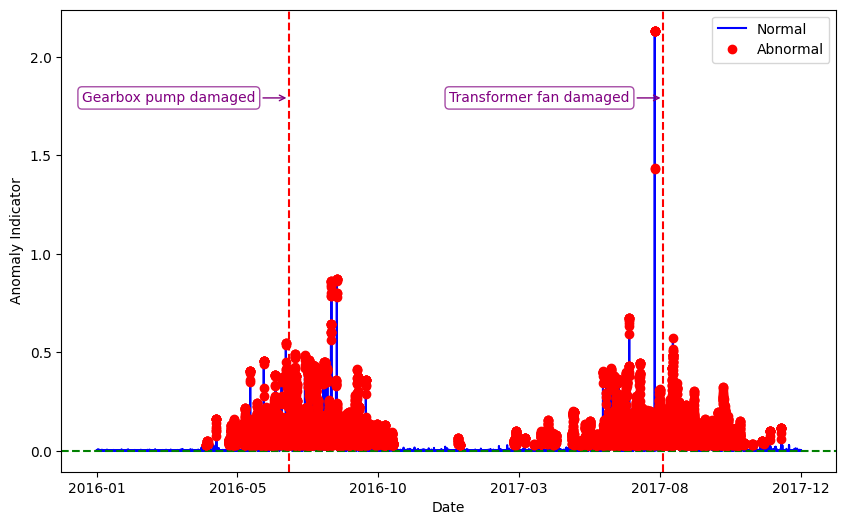

In [ ]:
list1 = list(f[f['Turbine_ID'] == 'T01']['Remarks'])
detect_change_points(df_result1['ReconstructionError'], df_result1,  dfT01, threshold=0.03, texts=list1, window_size=10, plot=True, pdf_filename='T01')

Int64Index([13639, 27591, 27990, 33834, 37901, 41460, 83579, 92059], dtype='int64')


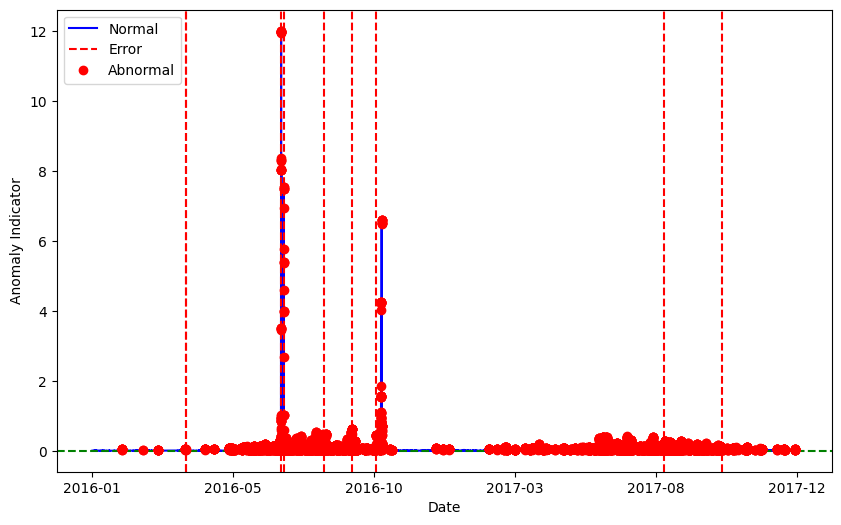

In [ ]:
list6 = list(f[f['Turbine_ID'] == 'T06']['Remarks'])
detect_change_points1(df_result6['ReconstructionError'], df_result6,  dfT06, threshold=0.03,  window_size=10, plot=True, pdf_filename='T06')

Int64Index([17346, 27489, 33817, 76545, 85556, 85752, 94150], dtype='int64')


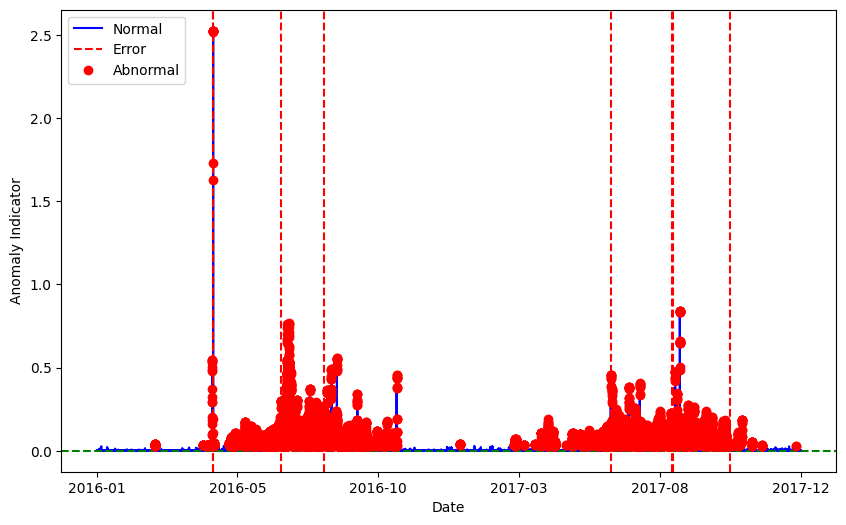

2     High temperature in generator bearing (replace...
3                          High temperature transformer
7     High temperature transformer. Transformer refr...
13                                   Oil leakage in Hub
16                           Generator bearings damaged
17                                    Generator damaged
20                                   Oil leakage in Hub
Name: Remarks, dtype: object

In [ ]:
detect_change_points1(df_result7['ReconstructionError'], df_result7,  dfT07, threshold=0.03, window_size=10, plot=True, pdf_filename='T07')
f[f['Turbine_ID'] == 'T07']['Remarks']

Int64Index([9038, 41602, 69106, 88920], dtype='int64')


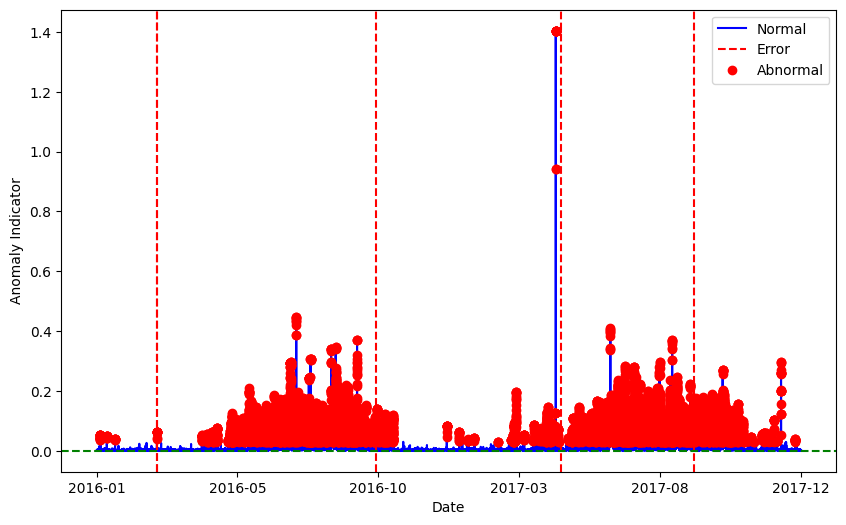

0            Electric circuit error in generator
10    Hydraulic group error in the brake circuit
12    Hydraulic group error in the brake circuit
18    Hydraulic group error in the brake circuit
Name: Remarks, dtype: object

In [ ]:
detect_change_points1(df_result11['ReconstructionError'], df_result11,  dfT11, threshold=0.03, window_size=10, plot=True, pdf_filename='T011')
f[f['Turbine_ID'] == 'T11']['Remarks']

# **4. Obtain useful failure type**

In [ ]:
#read results if you have saved them
df_result1=pd.read_csv('/content/drive/MyDrive/j2/df_result1.csv', index_col=0)
df_result6=pd.read_csv('/content/drive/MyDrive/j2/df_result6.csv', index_col=0)
df_result7=pd.read_csv('/content/drive/MyDrive/j2/df_result7.csv', index_col=0)
df_result11=pd.read_csv('/content/drive/MyDrive/j2/df_result11.csv', index_col=0)

In [ ]:
def analyze_and_print_segments(df_result, cut_points, dt_label):
    diff = np.diff(df_result['ReconstructionError'])
    rolling_std = np.std(np.lib.stride_tricks.sliding_window_view(diff, window_shape=(10,)), axis=1, ddof=0)
    change_point_indices = np.where(rolling_std > 0.03)[0]

    faulty_index = df_result[df_result['Fault'] != 0].index
    print(f"Faulty Index ({dt_label}): {faulty_index}")

    segments = np.split(change_point_indices, np.searchsorted(change_point_indices, cut_points))
    for i, segment in enumerate(segments):
        print(f"Segment {i} ({dt_label}): {len(segment)}")

    return diff, rolling_std, segments

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
cut_points1 = [0, 28632, 60000, 84217]
diff1, rolling_std1, segments1 = analyze_and_print_segments(df_result1, cut_points1, 'WT01')
#segment 0:till change point 1, seg 1: change point1 to first failure, seg2: after failure (repair stage) , seg 3: normal till the second failure, seg4: after failure

cut_points11 = [9038, 41602, 69106, 88920]
diff11, rolling_std11, segments11 = analyze_and_print_segments(df_result11, cut_points11, 'WT01')

cut_points7 = [19000, 27489, 60000, 76545]
diff7, rolling_std7, segments7 = analyze_and_print_segments(df_result7, cut_points7, 'WT7')

cut_points6 = [13699, 27591, 27990, 42000, 83579]
diff6, rolling_std6, segments6 = analyze_and_print_segments(df_result6, cut_points6, 'WT6')


Faulty Index (WT01): Int64Index([28632, 84217], dtype='int64')
Segment 0 (WT01): 0
Segment 1 (WT01): 3073
Segment 2 (WT01): 5903
Segment 3 (WT01): 5138
Segment 4 (WT01): 5447
Faulty Index (WT01): Int64Index([9038, 41602, 69106, 88920], dtype='int64')
Segment 0 (WT01): 49
Segment 1 (WT01): 8873
Segment 2 (WT01): 1059
Segment 3 (WT01): 8540
Segment 4 (WT01): 2797
Faulty Index (WT7): Int64Index([17346, 27489, 33817, 76545, 85556, 85752, 94150], dtype='int64')
Segment 0 (WT7): 113
Segment 1 (WT7): 2558
Segment 2 (WT7): 7238
Segment 3 (WT7): 1255
Segment 4 (WT7): 6890
Faulty Index (WT6): Int64Index([13639, 27591, 27990, 33834, 37901, 41460, 83579, 92059], dtype='int64')
Segment 0 (WT6): 30
Segment 1 (WT6): 1872
Segment 2 (WT6): 231
Segment 3 (WT6): 4287
Segment 4 (WT6): 5251
Segment 5 (WT6): 3662


In [ ]:
from statsmodels.tsa.stattools import adfuller

def plot_and_adf_test(segment_data, dff, title='Time Series Plot'):
    result = adfuller(dff[segment_data])
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:', result[4])
    if result[1] <= 0.05:
        print(f'\033[1;34mTime series of {title} is stationary.\033[0m')
    else:
        print(f'\033[1;34mTime series of {title} is not stationary.\033[0m')

def print_fit_info(poly_fit, time_series, values, label):
    print(f"Fit Information for {label}:")
    print("Coefficients:", poly_fit.coefficients)
    print("R-squared:", np.corrcoef(poly_fit(time_series), values)[0, 1]**2)
    print()

In [ ]:
plot_and_adf_test(segments1[1], rolling_std1, title='gearbox pump damage (WT1)')
print(segments1[1])
plot_and_adf_test(segments1[3], rolling_std1, title='transformer damage (WT1)')
print(segments1[3])
plot_and_adf_test(segments11[1],rolling_std11, title='hydraulic error (WT11)')
print(segments11[1])
plot_and_adf_test(segments11[3], rolling_std11, title='hydraulic error2 (WT11)')
print(segments11[3])
plot_and_adf_test(segments7[1], rolling_std7, title='Trans temp sensor (WT7)')

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


ADF Statistic: -9.686941623706156
p-value: 1.1637685077197004e-16
Critical Values: {'1%': -3.432500073267821, '5%': -2.862489965589418, '10%': -2.5672756908012313}
Time series of gearbox pump damage (WT1) is stationary.
[16214 16215 16216 ... 28629 28630 28631]
ADF Statistic: -10.17573308637902
p-value: 6.90057306292109e-18
Critical Values: {'1%': -3.4316318557684675, '5%': -2.8621064441775963, '10%': -2.5670715184860238}
Time series of transformer damage (WT1) is stationary.
[62031 62032 62033 ... 84214 84215 84216]
ADF Statistic: -12.709002636455214
p-value: 1.039968310683584e-23
Critical Values: {'1%': -3.431090289808259, '5%': -2.8618671593129177, '10%': -2.566944141908559}
Time series of hydraulic error (WT11) is stationary.
[15647 15648 15649 ... 41581 41582 41583]
ADF Statistic: -10.325941302453833
p-value: 2.9257866816968835e-18
Critical Values: {'1%': -3.4311189284467085, '5%': -2.8618798140661865, '10%': -2.5669508781237402}
Time series of hydraulic error2 (WT11) is stationar

In [ ]:
plot_and_adf_test(segments6[1], rolling_std6, title='Error in pitch regulation (WT6)')

ADF Statistic: -0.7073548437169876
p-value: 0.8448352585094361
Critical Values: {'1%': -3.4338896739040923, '5%': -2.863103567755513, '10%': -2.567602388312637}
Time series of Error in pitch regulation (WT6) is not stationary.


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
from scipy.interpolate import interp1d

def fit(df, segment_indices, name):
    fit_equations = {}
    for i, segment_index in enumerate(segment_indices):
        df['Timestamp'] = pd.to_datetime(df['Timestamp'])
        values = np.cumsum(df['ReconstructionError'].iloc[segment_index]) - df['ReconstructionError'].iloc[segment_index].iloc[0]
        time_series = (df['Timestamp'].iloc[segment_index] - df['Timestamp'].iloc[segment_index].iloc[0]).dt.total_seconds().astype(int) / (3600 * 24)

        print(max(time_series))
        values_normalized = 1-(values - min(values)) / max(values)
        interp_func = interp1d(time_series.values, values_normalized, kind='linear', fill_value="extrapolate")

        fit_equations[name[i]] = interp_func,max(time_series)
        print_fit_info(interp_func, time_series, values_normalized, name[i])
        plt.scatter(time_series, values_normalized, label=name[i])
        plt.plot(time_series, interp_func(time_series), color='red')

    plt.xlabel('Time (day)')
    plt.ylabel('Normalized Cumulative Reconstruction Error')
    plt.ylim(0, 1)
    plt.legend()
    plt.savefig('Degradation.pdf', format='pdf',bbox_inches='tight')
    #plt.close()  # Close the plot to avoid displaying it if saving as PDF
    return fit_equations

def print_fit_info(interp_func, x, y_original, name):
    pass

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
def fit(df, segment_indices, rolling_std, name):
    fit_equations = {}

    for i, segment_index in enumerate(segment_indices):
        df['Timestamp'] = pd.to_datetime(df['Timestamp'])
        values = np.cumsum(df['ReconstructionError'].iloc[segment_index]) - df['ReconstructionError'].iloc[segment_index].iloc[0]
        #values = np.cumsum(rolling_std[segment_index]-rolling_std[segment_index[0]])

        time_series = (df['Timestamp'].iloc[segment_index] - df['Timestamp'].iloc[segment_index].iloc[0]).dt.total_seconds().astype(int) / (3600 * 24)

        print(max(time_series))
        values_normalized = 1-(values - min(values)) / max(values)
        interp_func = interp1d(time_series.values, values_normalized, kind='linear', fill_value="extrapolate")

        fit_equations[name[i]] = interp_func,max(time_series)
        print_fit_info(interp_func, time_series, values_normalized, name[i])

        plt.scatter(time_series, values_normalized, label=name[i])
        plt.plot(time_series, interp_func(time_series), color='red')

    plt.xlabel('Time (day)')
    plt.ylabel('Normalized Cumulative Reconstruction Error')
    plt.ylim(0, 1)
    #plt.title('Comparison of Data and Interpolation Fits')
    plt.legend()
    plt.savefig('Degradation.pdf', format='pdf',bbox_inches='tight')
    #plt.close()  # Close the plot to avoid displaying it if saving as PDF

    return fit_equations

def print_fit_info(interp_func, x, y_original, name):
    pass

77.30555555555556
86.41666666666667
155.93055555555554
54.50694444444444
131.91666666666666


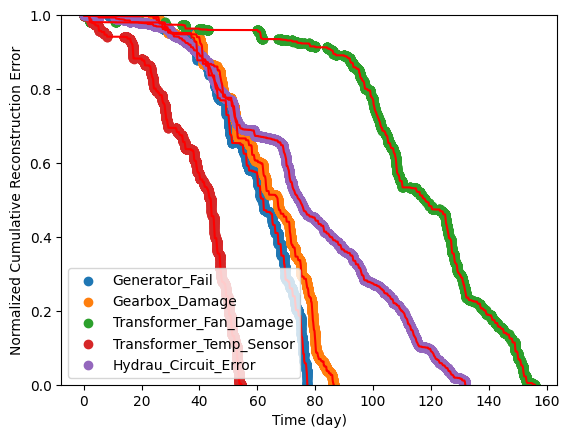

In [ ]:
#plt.figure(figsize=(20, 10))
fit_equations6=fit(df_result6, [segments6[1]],rolling_std6, ['Generator_Fail'])
fit_equations1=fit(df_result1, [segments1[1], segments1[3]], rolling_std1,['Gearbox_Damage','Transformer_Fan_Damage'])
fit_equations7=fit(df_result7, [segments7[1]], rolling_std7, ['Transformer_Temp_Sensor'])
fit_equations11=fit(df_result11, [segments11[3]], rolling_std11, ['Hydrau_Circuit_Error'])
#plt.show()

# **5. Functions (generate degradation)**

In [ ]:
#add failure rate per year (for longer simulation, no effect in short term)
fit_equations1['Gearbox_Damage'] += (0.18/365,)
fit_equations1['Transformer_Fan_Damage'] += (0.27/365,)
fit_equations7['Transformer_Temp_Sensor'] += (0.08/365,)
fit_equations11['Hydrau_Circuit_Error'] += (0.26/365,)
fit_equations6['Generator_Fail'] +=  (0.08/365,)
fitss=[fit_equations1,fit_equations7,fit_equations6,fit_equations11]

In [ ]:
fit_combined = {key: value for fit_equation_dict in fitss for key, value in fit_equation_dict.items()}

In [ ]:
#Uniform distribution wrt. failure rate
def generate_rul_curve(fit_combined, total_days):
  rul_curves = {}
  for equation_name, (model, max_day, lam) in fit_combined.items():
    event_time_points = np.arange(0, total_days, 1/(lam))
    event_time_points = event_time_points.astype(int)
    rul_curve = np.ones(total_days)
    if len(event_time_points) > 0:
      x_values = np.arange(math.ceil(max_day) + 1)
      y_value = np.clip(model(x_values), 0, 1)
      num_zeros = 1000000  #after 1000000th day from failure, do corrective maintenance
      zeros_to_insert = np.zeros(num_zeros)
      y_val = np.concatenate([y_value, zeros_to_insert])
      for i in event_time_points:
        if rul_curve[i]==1:
          slice_length = min(len(rul_curve[i:]), len(y_val))
          rul_curve[i:i + slice_length] = y_val[:slice_length]
          rul_curves[equation_name] = rul_curve
  return  rul_curves

def update_rul(fit_combined, equation_name, v): #update from current day+1
  updated_rul_curves = {}
  model, max_day, lam = fit_combined[equation_name]
  x_values = np.arange(math.ceil(max_day) + 1)
  y_values =  np.clip(model(x_values), 0, 1)
  y_values_isotonic =  y_values[y_values <= v]
  zeros_to_add = np.zeros(1000) #no repair action after failure
  y_values_isotonic = np.concatenate((y_values_isotonic, zeros_to_add))
  updated_rul_curves[f"{equation_name}"] = y_values_isotonic
  return updated_rul_curves

def generate_cul_curve(rul_curves,total_days):
    cul_curve = np.ones(total_days)
    for day in range(total_days):
        components = [rul_curves[key][day] for key in ['Gearbox_Damage', 'Generator_Fail', 'Transformer_Fan_Damage', 'Hydrau_Circuit_Error', 'Transformer_Temp_Sensor']]
        parallelfail =  (1 - components[3]) * (1 - components[4])
        mechanical = np.prod(components[:3]) *  (1-0.00001 * parallelfail) # sensor failure influence
        cul_curve[day] = mechanical
    return cul_curve

In [ ]:
pip install Gpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 36.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 14.8 MB/s eta 0:00:00


In [ ]:
#GPR model
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
import GPy

def gaussian_process_regression(x, y):
    x = x.reshape(-1, 1)
    y = y.reshape(-1, 1)
    kernel = GPy.kern.Matern32(input_dim=1, lengthscale=2, variance=1)
    mapping = GPy.mappings.Linear(input_dim=1, output_dim=1)
    model = GPy.models.GPRegression(x, y, mean_function= mapping, kernel=kernel)
    model.optimize_restarts(optimizer='lbfgs',num_restarts=50, verbose=False)
    return model

def gussianmodel(rul,startime, obtime, pretime):
  dictpre =  {}
  x_values = np.arange(startime, obtime, 1)
  x_pred = np.arange(obtime, pretime, 1).reshape(-1, 1)

  for equation_name, rul_curve in rul.items():
    observed_data = rul_curve[startime:obtime]
    gp = gaussian_process_regression(x_values, observed_data)
    y_pred, y_var = gp.predict(x_pred , full_cov=True)
    y_std = np.sqrt(np.diag(y_var)).reshape(-1, 1)
    y_pred= np.clip(y_pred, 0, 1)
    dictpre[equation_name] = {'x_pred': x_pred.flatten(),
            'y_pred': y_pred.flatten(),
            'y_std': y_std.flatten()}
  return dictpre

# Plot Degadation and its predictions

First Zero Indices: {'Gearbox_Damage': 87, 'Transformer_Fan_Damage': 156, 'Transformer_Temp_Sensor': 55, 'Generator_Fail': 78, 'Hydrau_Circuit_Error': 132}


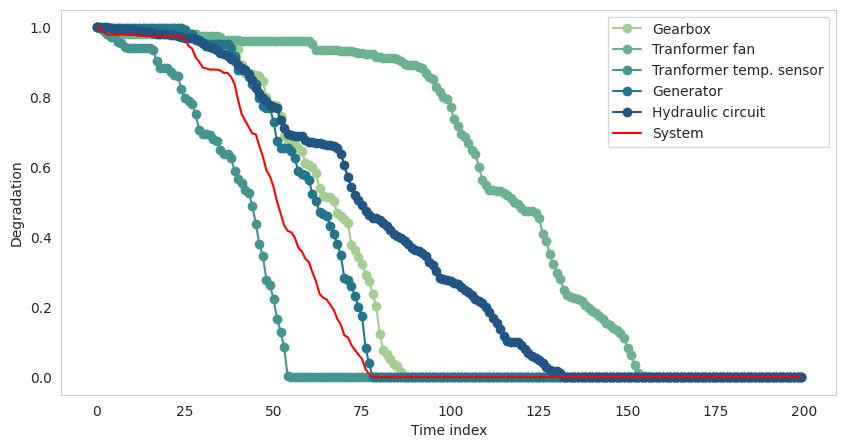

In [ ]:
sns.set_style("whitegrid")
cmap = sns.color_palette("crest", as_cmap=True)
#cmap = sns.color_palette("ch:start=.2,rot=-.3", as_cmap=True)

total_days = 200
rul = generate_rul_curve(fit_combined, total_days)
cul = generate_cul_curve(rul, total_days)
first_zero_indices = {key: np.where(values == 0)[0][0] if 0 in values else None for key, values in rul.items()}

#print the life time of components
print("First Zero Indices:", first_zero_indices)

plt.figure(figsize=(10, 5))

# Plotting system failure probability with red color
# Plotting individual equations with the mako color palette
labels= {'Gearbox_Damage': 'Gearbox',
 'Transformer_Fan_Damage': 'Tranformer fan',
 'Transformer_Temp_Sensor':'Tranformer temp. sensor',
 'Hydrau_Circuit_Error': 'Hydraulic circuit',
 'Generator_Fail':'Generator'}

for i, (equation_name, rul_curve) in enumerate(rul.items()):
    plt.plot(np.arange(total_days), rul_curve, '-o', label=f'{labels[equation_name]}', color=cmap(i/ len(rul)))

plt.plot(cul, label='System', color='red')

plt.xlabel('Time index')
plt.ylabel('Degradation')
plt.legend()
plt.grid(False)
plt.savefig('relia.pdf', bbox_inches='tight')
plt.show()

In [ ]:
total_days=365
rul = generate_rul_curve(fit_combined,total_days)
cul = generate_cul_curve(rul,total_days)
dictpre= gussianmodel(rul, 0, 45, 85)

 /usr/local/lib/python3.10/dist-packages/GPy/kern/src/stationary.py:168: RuntimeWarning:overflow encountered in divide
 /usr/local/lib/python3.10/dist-packages/GPy/kern/src/stationary.py:489: RuntimeWarning:overflow encountered in multiply
 /usr/local/lib/python3.10/dist-packages/GPy/kern/src/stationary.py:489: RuntimeWarning:invalid value encountered in multiply
 /usr/local/lib/python3.10/dist-packages/GPy/kern/src/stationary.py:492: RuntimeWarning:overflow encountered in multiply
 /usr/local/lib/python3.10/dist-packages/GPy/kern/src/stationary.py:492: RuntimeWarning:invalid value encountered in multiply


In [ ]:
#plot predictions of GPR、
def plot_predictions(rul, dictpre,startime, obtime):
    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 6))
    cmap = sns.color_palette("crest", as_cmap=True)
    equation_names = list(rul.keys())
    num_equations = len(equation_names)

    color_dict = {equation_name: cmap(i / num_equations) for i, equation_name in enumerate(equation_names)}

    for equation_name in rul.keys():
        rul_curve = rul[equation_name]
        x_values = np.arange(startime, obtime, 1)
        pred_data = dictpre[equation_name]
        x_pred = pred_data['x_pred']
        y_pred = pred_data['y_pred']
        y_std = pred_data['y_std']
        combined_x = np.concatenate([x_values, x_pred])

        #note the trend cannot increase
        plt.fill_between(x_pred, np.clip((y_pred+ 2* y_std).flatten(),0, rul_curve[startime:obtime+len(x_pred)][obtime-1]), np.clip((y_pred- 4* y_std).flatten(),0,rul_curve[startime:obtime+len(x_pred)][obtime-1]), alpha=0.3, color=color_dict[equation_name])

        plt.scatter(combined_x, rul_curve[startime:obtime+len(x_pred)], label=f"Observation ({equation_name})", color=color_dict[equation_name])
        plt.plot(x_pred, y_pred, label=f"Prediction ({equation_name})",c=color_dict[equation_name])
        #plt.scatter (x_pred, rul_curve[obtime:obtime+len(x_pred)],  label=f"Prediction {equation_name}")

    #plt.title("Gaussian Process Regression")
    plt.xlabel("Time index")
    plt.ylabel("Degradation")
    plt.legend(loc='lower left', fontsize='small')
    plt.grid(False)
    plt.savefig('pred.pdf', bbox_inches='tight')

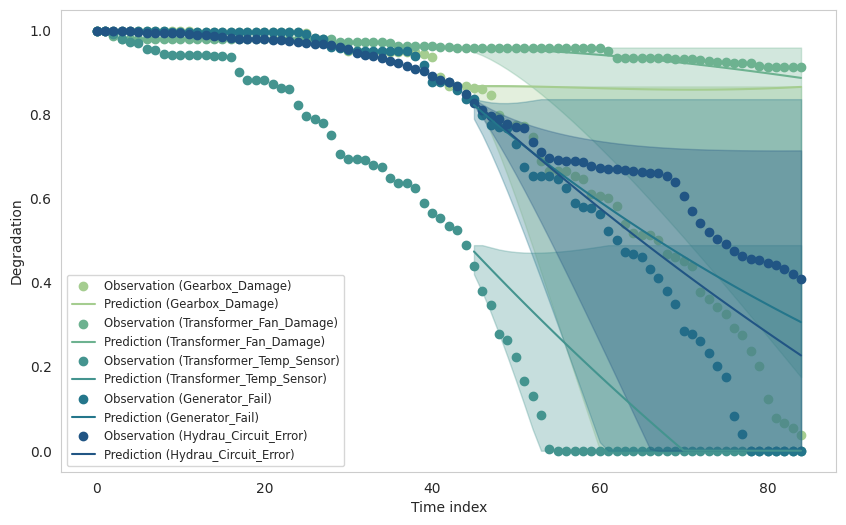

In [ ]:
plot_predictions(rul, dictpre, 0, 45)

# **6. Functions (generate electricity price and wind)**

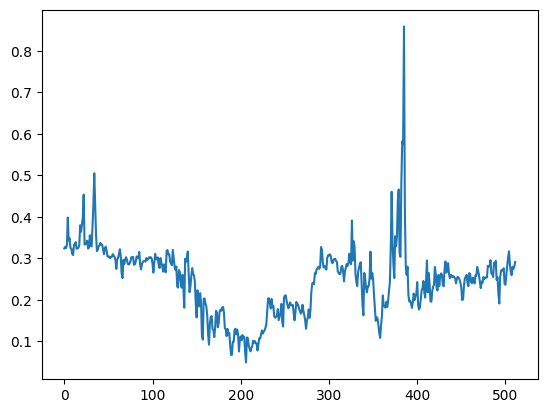

In [ ]:
def generate_electricity_price(time, df):
  elec = df['Price (EUR/MWhe)'][:time]*11.74/1000
  price = elec.tolist()
  price = [max(0, p) for p in price]
  return price

#generate electricity price from data
elec = generate_electricity_price(256*2, norelec)
plt.plot(elec)

51
Fitted Parameters: [ 8.35628938e-08 -1.11083379e-06 -5.95574347e-06 -3.98587113e-06
  2.13115118e-04  5.44495149e-03  8.19212695e-02  7.58763135e-01
  1.81200474e+00  2.82020183e-02 -7.84969955e+00]
Minimum Loss Value: 621.1799114759256


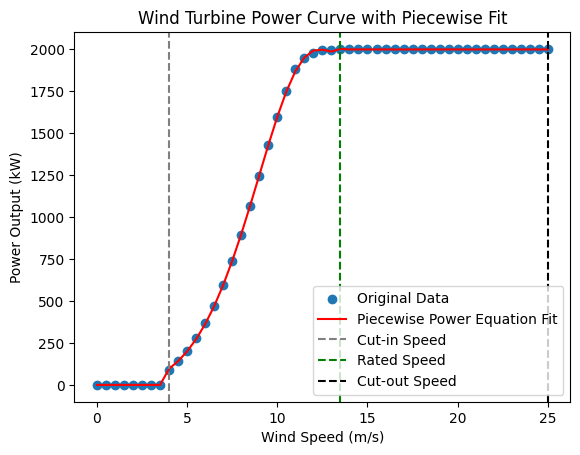

In [ ]:
#fit power curve
from scipy.optimize import minimize

# wind turbine parameter
rotor_diameter = 90  # m
rho = 1.225 # air density kg/m** 3
cut_in_speed = 4   #m/s
cut_out_speed = 25 #m/s
rated_speed = 13.5 #m/s
area= 6362 #swept area squared meters
power_curve = {0:0, 0.5:0, 1:0, 1.5:0,2:0, 2.5:0, 3:0, 3.5:0,
               4: 89, 4.5: 142, 5: 204, 5.5: 279,
6: 368, 6.5:470,7: 594, 7.5:736,
8:896, 8.5: 1069, 9:1247, 9.5:1428,
10:1599, 10.5:1753, 11:1881, 11.5:1951,
12:1981,12.5:1994, 13:1998, 13.5:2000,
14:2000,14.5:2000,15:2000,15.5:2000,
16:2000,16.5:2000,17:2000,17.5:2000,
18:2000,18.5:2000,19:2000,19.5:2000,
20:2000,20.5:2000,21:2000,21.5:2000,
22:2000,22.5:2000,23:2000,23.5:2000,
24:2000,24.5:2000,25:2000}
power=11

def piecewise_power_equation(x, params, power):
    poly_fit = np.poly1d(params[:power])
    return np.piecewise(x, [x < cut_in_speed, (cut_in_speed <= x) & (x <= rated_speed), (rated_speed < x) & (x <= cut_out_speed), x > cut_out_speed],
                        [0, np.poly1d(params[:power]), 2000, 0])

wind_speeds = np.array(list(power_curve.keys()))
power_outputs = np.array(list(power_curve.values()))

print(len(power_outputs))

# define loss function
def loss_function(params):
    return np.sum((power_outputs - piecewise_power_equation(wind_speeds, params,power))**2)

# fit functions
result = minimize(loss_function, x0=[0] * power,method='Powell')

#parameters
fit_params = result.x
print("Fitted Parameters:", fit_params)
print("Minimum Loss Value:", result.fun)

fit_power = piecewise_power_equation(wind_speeds, fit_params, power)
plt.scatter(wind_speeds, power_outputs, label="Original Data")
plt.plot(wind_speeds, fit_power, label="Piecewise Power Equation Fit", color='red')
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Power Output (kW)")
plt.title("Wind Turbine Power Curve with Piecewise Fit")
plt.axvline(x=cut_in_speed, linestyle='--', color='gray', label='Cut-in Speed')
plt.axvline(x=rated_speed, linestyle='--', color='green', label='Rated Speed')
plt.axvline(x=cut_out_speed, linestyle='--', color='black', label='Cut-out Speed')
plt.legend()
plt.show()

In [ ]:
#obtain wind speed from dfT01
dfT01['Timestamp'] = pd.to_datetime(dfT01['Timestamp'])
dfT01.set_index('Timestamp', inplace=True)
windspeed = dfT01['Amb_WindSpeed_Avg'].resample('D').mean()
print(windspeed)

Timestamp
2016-01-01    5.070833
2016-01-02    3.823611
2016-01-03    5.527083
2016-01-04    9.439583
2016-01-05    9.043056
                ...   
2017-12-27    9.475000
2017-12-28    7.905556
2017-12-29    4.592361
2017-12-30    2.675694
2017-12-31    4.193056
Freq: D, Name: Amb_WindSpeed_Avg, Length: 731, dtype: float64


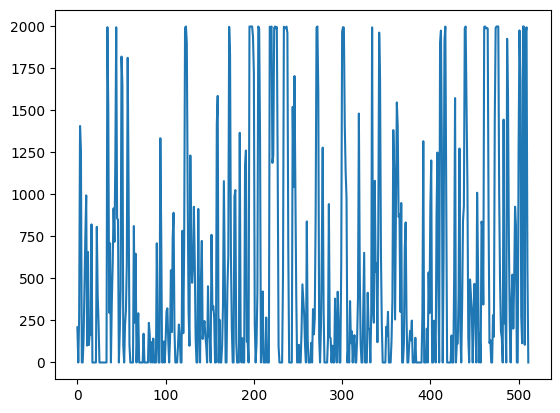

In [ ]:
def generate_wind(time, windspeed):
  wind = windspeed[:time] #*11.74/1000
  wind = wind.tolist()
  wind = [max(0,w) for w in wind]
  return wind

wind = generate_wind(256*2, windspeed)

#plot power under ideal conditions
powerg = piecewise_power_equation(np.array(list(wind)), fit_params, power)
#plt.plot(wind)
plt.plot(powerg)

# **7. Build environment and DE algorithm**

In [ ]:
class CustomEnv(gym.Env):
    def __init__(self, fit_combined, total_days):
        #pre-setting
        self.component_prices = {'Gearbox_Damage': 10000, 'Transformer_Fan_Damage': 24423, 'Transformer_Temp_Sensor': 700,'Generator_Fail': 20000, 'Hydrau_Circuit_Error': 100}
        self.repairT= {'Gearbox_Damage': 1, 'Transformer_Fan_Damage': 1, 'Transformer_Temp_Sensor': 1, 'Generator_Fail':1, 'Hydrau_Circuit_Error':1}
        self.key = list(self.component_prices.keys())
        self.fitss = fit_combined
        self.total_days = total_days

        #initial
        self.current_day = 0
        self.state = np.zeros((1, 6))
        self.reward = 0

        #generation
        self.rul = generate_rul_curve(self.fitss, self.total_days)
        self.cul = generate_cul_curve(self.rul, self.total_days)
        self.elec = generate_electricity_price(self.total_days, norelec)

        #print("Maximal elec price:", max(self.elec))
        #print("Minimal elec price:", min(self.elec))

        self.wind = generate_wind(self.total_days, windspeed)

        #print("Maximal wind:", max(self.wind))
        #print("Minimal wind:", min(self.wind))

        self.power = piecewise_power_equation(np.array(list(self.wind)), fit_params, power)

        self.profit = self.elec*self.power #ideal profits without degradation

        #print("Maximal elec profit:", self.profit)

        self.component_prices = np.array([self.component_prices[comp] for comp in self.key])
        #time parameters
        self.gap= 45 # monitoring window
        self.gap2= 56 # maintenance window

        self.indicator = False  #indicates termination
        self.min_price_day = self.gap +np.argmin(self.elec[self.gap: self.gap2]) #can be deleted

        self.state[0, :] = np.concatenate(([self.cul[0]], [self.rul[comp][0] for comp in self.key])) #monitor system and component states
        self.i = np.arange(self.gap, self.total_days)
        self.reRUL = {comp: self.rul[comp][self.gap:] for comp in self.key}

    def predict(self):
        self.dictpre= gussianmodel(self.rul, 0, self.gap, self.total_days)

    def prereset(self, attitude):
          self.real_rul_dict = {}
          for equation_name, pred_data in self.dictpre.items():
            if attitude == "optimal":
              self.real_rul_dict[equation_name] = np.clip(pred_data['y_pred'] + 2 * pred_data['y_std'], 0, self.rul[equation_name][self.gap-1])
            elif attitude == "pessimistic":
              self.real_rul_dict[equation_name] = np.clip(pred_data['y_pred'] - 4* pred_data['y_std'], 0, self.rul[equation_name][self.gap-1])
            elif attitude == "real":
              self.real_rul_dict[equation_name] = self.reRUL[equation_name]
            elif attitude == "neutral":
              self.real_rul_dict[equation_name] = np.clip(pred_data['y_pred'] - 0 * pred_data['y_std'], 0, self.rul[equation_name][self.gap-1])

          return self.real_rul_dict

    def reset(self):
        self.current_day = 0
        self.rul = {component: np.ones(self.total_days) for component in self.key}
        self.rul = generate_rul_curve(self.fitss, self.total_days)

        #reset by attitude
        for comp in self.key:
          self.rul[comp][self.gap+1:] = self.real_rul_dict[comp][1:self.total_days-self.gap]

        self.cul = generate_cul_curve(self.rul, self.total_days)
        self.state[0, :] = np.concatenate(([self.cul[self.current_day]], [self.rul[comp][self.current_day] for comp in self.key]))
        self.i = np.arange(self.gap, self.total_days)
        self.reward = 0
        repair_levels = np.zeros(5)
        self.indicator = False

        return self.state

    def step(self, action):
        discrete_action = int(action[0])
        continuous_action = action[1:]
        self.indicator = (self.current_day == self.gap + discrete_action)

        if self.indicator == True:
          action_space_high = 1 - np.array([self.rul[component][self.current_day] for component in self.key])
          clipped_action = np.clip(continuous_action, np.zeros(5), action_space_high)
          repair_levels = clipped_action

          self.repair_system(repair_levels)
          self.cul = generate_cul_curve(self.rul, self.total_days)
          cost = self.calculate_cost(continuous_action)
          self.reward = self.calculate_reward(cost)

        self.state[0, :] = np.concatenate(([self.cul[self.current_day]], [self.rul[comp][self.current_day] for comp in self.key]))
        self.current_day += 1

        return self.reward

    def repair_system(self, repair_levels):
        for component, repair_level in zip(self.key, repair_levels):
            if self.rul[component][self.current_day] != 1 and repair_level!= 0:
              newlevel= min(1.0, self.rul[component][self.current_day] + repair_level)
              filtered_values = [value for value in self.rul[component] if value <= newlevel]
              start_index = self.current_day + self.repairT[component] #repair time 1 day

              self.rul[component][self.current_day:start_index]=  [0] * (start_index - self.current_day)

              end_index = min(start_index + len(filtered_values), self.total_days)
              lend= end_index - start_index
              if lend > 0:
                self.rul[component][start_index:end_index] = filtered_values[:lend]
            else:
                 repair_level =0

    def calculate_reward(self, cost, gam=1):
        discount = gam ** (self.i -self.gap)
        future_production = np.sum(24 * self.cul[self.i] * discount[self.i -self.gap] * self.profit[self.i])
        total_reward = future_production-cost
        return total_reward

    def calculate_cost(self, continuous_action):
        component_costs = continuous_action * self.component_prices
        if np.sum(continuous_action) == 0:
          shipping_cost = 0
        else:
          shipping_cost = 15000
        total_cost = np.sum(component_costs) + shipping_cost
        return total_cost

    def cm(self, threshold):
        if self.cul[self.current_day] <= threshold:
          repair_levels = np.ones(5) - np.array([self.rul[component][self.current_day] for component in self.key])
          print(repair_levels)
          print(self.current_day)
          self.repair_system(repair_levels)
          self.cul = generate_cul_curve(self.rul, self.total_days)
          cost = self.calculate_cost(repair_levels)
          self.reward = self.calculate_reward(cost)

        self.state[0, :] = np.concatenate(([self.cul[self.current_day]], [self.rul[comp][self.current_day] for comp in self.key]))
          #return self.reward
        self.current_day += 1
        return self.reward

In [ ]:
#dynamic differential algorithm
import multiprocessing
from multiprocessing import Pool

def evaluate_single_action(args):
    action, environment, timesteps = args
    env.reset()
    for current_timestep in range(env.gap, timesteps):
        env.current_day = current_timestep
        reward = env.step(action)
        if env.indicator:
            return reward
            break
    return reward

def evaluate_actions_parallel(population, environment, timesteps):
    with Pool() as pool:
        results = pool.map(evaluate_single_action, [(action, environment, timesteps) for action in population])
    return np.array(results)

def generate_random_action(day):
    first_element =np.random.randint(0, int(day)) #uniform distribution
    other_elements = np.random.uniform(0, 1, size=5)
    random_action = np.concatenate(([first_element], other_elements))
    return random_action

def evolve_individual(args):
    i, population, fitness_scores, bounds, environment, timesteps, deyna = args
    selected_index = np.random.choice(np.argsort(fitness_scores)[::-1][:int(0.05 * len(population))])
    selected_individual = population[selected_index]

    mutant =  selected_individual + deyna * (population[np.random.choice(len(population))] - population[np.random.choice(len(population))])
    mutant = np.clip(mutant, bounds[:, 0], bounds[:, 1])

    crossover_mask = np.random.rand(6) < 1

    trial = np.where(crossover_mask, mutant, population[i])

    if evaluate_single_action((trial, environment, timesteps)) > fitness_scores[i]:
        return trial
    else:
        return population[i]

class DEParameters:
    def __init__(self, num_generations, population_size, std_dev):
        self.num_generations = num_generations
        self.population_size = population_size
        self.std_dev = std_dev

    def dyna(self, generation):
        weights = np.random.standard_cauchy(self.population_size)+self.std_dev
        return weights

#parallel computing
def evolve_population_parallel(population_size, num_generations, environment, timesteps, std_dev, condition, early_stopping_generations=30):
    day = env.gap2 - env.gap
    population = [generate_random_action(day) for _ in range(population_size)]

    bounds = np.array([[1, int(day)], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1]])

    best_reward = -np.inf
    early_stopping_counter = 0

    de_params = DEParameters(num_generations, population_size, std_dev)
    rewardlist= []
    for generation in range(num_generations):
        fitness_scores = evaluate_actions_parallel(population, environment, timesteps)
        deyna = de_params.dyna(generation)
        with Pool() as pool:
            population = pool.map(evolve_individual, [(i, population, fitness_scores, bounds, environment, timesteps, deyna[i]) for i in range(population_size)])

        current_best_reward = np.max(fitness_scores)

        if current_best_reward > best_reward+0.5:
            best_reward = current_best_reward
            early_stopping_counter = 0
        else:
            early_stopping_counter += 1

        rewardlist.append(best_reward)

        if condition:
          print(f"Generation {generation + 1}, Best Reward: {best_reward}")

        if early_stopping_counter >= early_stopping_generations:
            print(f"Early stopping after {early_stopping_generations} generations with no improvement.")
            break

    return population[np.argmax(fitness_scores)], best_reward, rewardlist

# Set a env model (jump)

In [ ]:
num_cpus = multiprocessing.cpu_count()
print(f"Number of available CPUs: {num_cpus}")

Number of available CPUs: 8


In [ ]:
#save model with predictions (for rreplication) #ignore warnings
timesteps = 100
env = CustomEnv(fit_combined, total_days=timesteps)
env.predict()
env.total_days=100
with open('/content/drive/MyDrive/j2/environment.pkl', 'wb') as file:
    pickle.dump(env, file)

# **8. OM**

In [ ]:
#load old env with prediction
with open('/content/drive/MyDrive/j2/environment.pkl', 'rb') as file:
    env = pickle.load(file)

# **8.1 CBM strategy**

In [ ]:
#Corrective maintenance /preventive maintenance
attitude = "real"
env.total_days = 60
env.prereset(attitude)
env.reset()

print(f"Degradation at {env.gap2+1}th day:", env.cul[env.gap2])
print(f"Degradation at {env.total_days}th day:", env.cul[env.total_days-1])
print(f"Degradation at {env.gap+1}th day:", env.cul[env.gap])

generated_values = np.linspace(env.cul[env.gap], env.cul[env.gap2], 30)
rounded_values = np.round(generated_values, 2)
print("Degradation levels of CBM: ", rounded_values)

Degradation at 57th day: 0.3993722087240759
Degradation at 60th day: 0.338735626323021
Degradation at 46th day: 0.6937777322838193
Degradation levels of CBM:  [0.69 0.68 0.67 0.66 0.65 0.64 0.63 0.62 0.61 0.6  0.59 0.58 0.57 0.56
 0.55 0.54 0.53 0.52 0.51 0.5  0.49 0.48 0.47 0.46 0.45 0.44 0.43 0.42
 0.41 0.4 ]


In [ ]:
rew=[] #collect reward
for rounded_value in rounded_values:
  attitude = "real"
  env.total_days = 60
  env.prereset(attitude)
  env.reset()
  #print( "t",  rounded_value)
  for current_timestep in range(0, env.total_days):
    env.current_day = current_timestep
    reward= env.cm(rounded_value)
    if reward != 0:
      #print(reward)
      rew.append(reward)
      break

[0.138738   0.04012836 0.62037187 0.20081627 0.18907714]
46
[0.138738   0.04012836 0.62037187 0.20081627 0.18907714]
46
[0.138738   0.04012836 0.62037187 0.20081627 0.18907714]
46
[0.15312818 0.04012971 0.65422194 0.22458074 0.20246538]
47
[0.15312818 0.04012971 0.65422194 0.22458074 0.20246538]
47
[0.15312818 0.04012971 0.65422194 0.22458074 0.20246538]
47
[0.19983645 0.04013107 0.72141501 0.23030556 0.21067286]
48
[0.19983645 0.04013107 0.72141501 0.23030556 0.21067286]
48
[0.19983645 0.04013107 0.72141501 0.23030556 0.21067286]
48
[0.19983645 0.04013107 0.72141501 0.23030556 0.21067286]
48
[0.22309306 0.04013243 0.73638953 0.23048292 0.22139038]
49
[0.22309306 0.04013243 0.73638953 0.23048292 0.22139038]
49
[0.22344976 0.04013378 0.77781988 0.27047436 0.22831329]
50
[0.22344976 0.04013378 0.77781988 0.27047436 0.22831329]
50
[0.22344976 0.04013378 0.77781988 0.27047436 0.22831329]
50
[0.22609881 0.04013514 0.83303919 0.32546039 0.23055263]
51
[0.22609881 0.04013514 0.83303919 0.3254

In [ ]:
print('Max profit:',max(rew))
print('Min profit:',min(rew))
#collect from output
daylist = [46, 46, 46, 47, 47, 47, 48, 48, 48, 48, 49, 49, 50, 50, 50, 51, 51, 51, 51, 52, 52, 52, 52, 53, 53, 53, 54, 54, 56, 56]

Max profit: 45470.35093006866
Min profit: 20520.428118672065


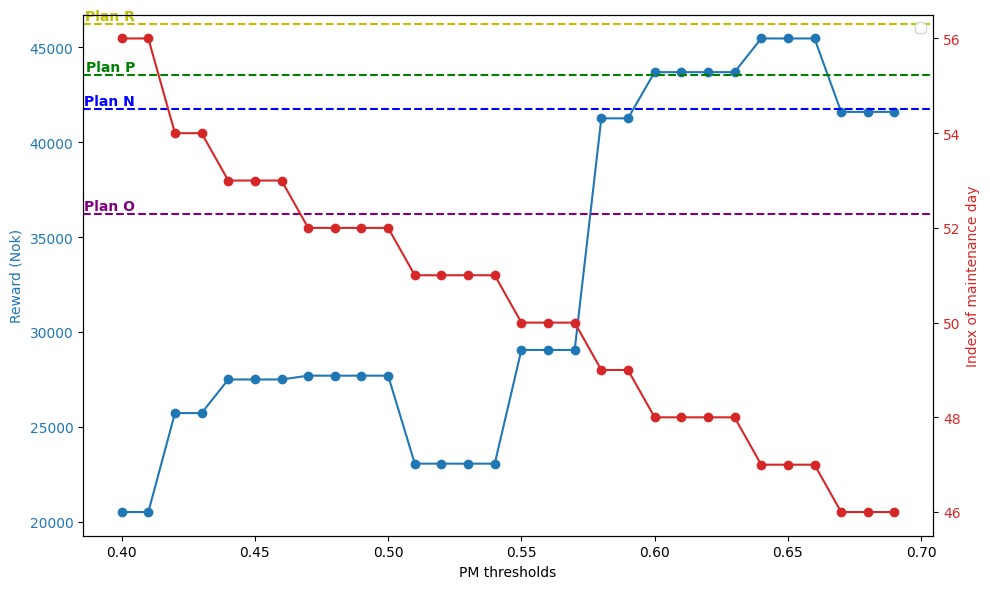

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))
color1 = 'tab:blue'
ax1.set_xlabel('PM thresholds')
ax1.set_ylabel('Reward (Nok)', color=color1)
ax1.plot(rounded_values, rew, marker='o', linestyle='-', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.axhline(y=36209.34, color='purple', linestyle='--', label='Plan O')
ax1.axhline(y=43540.29, color='g', linestyle='--', label='Plan P')
ax1.axhline(y=41771.21, color='b', linestyle='--', label='Plan N')
ax1.axhline(y=46245.56, color='y', linestyle='--', label='Plan R')
xloc=rounded_values[-1]+0.005
ax1.text(xloc, 36239.34+400, 'Plan O', ha='right', va='center', color='purple', fontweight='bold')
ax1.text(xloc, 43540.29+400, 'Plan P', ha='right', va='center', color='g', fontweight='bold')
ax1.text(xloc, 41771.21+400, 'Plan N', ha='right', va='center', color='b', fontweight='bold')
ax1.text(xloc, 46245.56+400, 'Plan R', ha='right', va='center', color='y', fontweight='bold')

ax3 = ax1.twinx()
color3 = 'tab:red'
ax3.set_ylabel('Index of maintenance day', color=color3)
ax3.plot(rounded_values, daylist, marker='o', linestyle='-', color=color3)
ax3.tick_params(axis='y', labelcolor=color3)
plt.legend()
fig.tight_layout()
plt.savefig('PM.pdf',bbox_inches='tight')
plt.show()

# **8.2 Define evaluation functions for PdM**

In [ ]:
#rounded values
def turn(rep):
  exper_rep=rep.copy()
  exper_rep['Best_Action'] = exper_rep['Best_Action'].apply(lambda x: [int(x[0])] + [round(elem, 7) for elem in x[1:]]).astype('object')
  exper_rep['Best_Date'] = exper_rep['Best_Action'].apply(lambda x:x[0])
  se = exper_rep.iloc[:, [0, 1, 2, 3, 5,6]].round(3)
  se['Best_Action']=se['Best_Action'].apply(lambda x: x[1:]).astype('object')
  return se

#plot results
def plotexp(expr1,name):
  plt.figure(figsize=(10, 6))
  cmap_blue = plt.cm.Blues
  for i, row in expr1.head(10).iterrows():
    gen_length = list(range(1, len(row['Reward_List']) + 1))
    color = cmap_blue((i + 1) / 10)

    #label_text = f'Pop Size = {row["Pop_Size"]}, Loc = {row["Std_Dev"]:.2f}'
    plt.plot(gen_length, list(row['Reward_List']), color=color)
  plt.legend(loc='lower right',  ncol=2)
  plt.savefig(name,bbox_inches='tight')
  plt.show()

#find the best action with the highest reward
def bestac(dfxx):
  mer= dfxx.loc[dfxx['Best_Reward'].idxmax()]
  act=mer['Best_Action']
  return act

#evaluate reward
def evaluteSingle(action, scenario):
    env.prereset(scenario)
    env.reset()
    env.total_days=60
    for current_timestep in range(env.gap, env.total_days):
      env.current_day= current_timestep
      reward = env.step(action)
      if env.indicator:
        break
    return(reward)

#evaluate degradation states
def evaluteSingleR(action, scenario):
    cull=None
    rull=None
    env.prereset(scenario)
    env.reset()
    env.total_days=60
    for current_timestep in range(env.gap, env.total_days):
      env.current_day= current_timestep
      reward = env.step(action)
      if env.indicator:
        cull=env.cul
        rull=env.rul
        break
    return cull, rull

In [ ]:
#same params
import time
def rep(nums, population_size,std_dev_value, toal, attitude):
  expr_rep = pd.DataFrame(columns=['Pop_Size', 'Std_Dev', 'Best_Reward', 'Best_Action', 'Reward_List', 'Execution_Time'])
  for _ in range(nums):
    start_time = time.time()
    env.prereset(attitude)
    env.total_days= toal
    best_action, best_reward, reward_list = evolve_population_parallel(population_size, num_generations=200, environment=env, timesteps=toal, std_dev=std_dev_value, condition=False)
    end_time = time.time()
    execution_time = end_time - start_time
    # Concatenate the results to the existing DataFrame
    expr_rep = pd.concat([expr_rep, pd.DataFrame({'Pop_Size': [population_size], 'Std_Dev': [std_dev_value], 'Best_Reward': [best_reward], 'Best_Action': [best_action], 'Reward_List': [reward_list], 'Execution_Time': [execution_time]})], ignore_index=True)
  return expr_rep

# Show plots of results (jump)

In [ ]:
action2=np.array([10, 0 ,0, 0, 0, 0])

#read actions if you have trained it
with open('/content/drive/MyDrive/j2/actions.txt', 'r') as file:
    content = file.read()

lines = content.split('\n')

actions_dict = {}

# Iterate through lines and separate actions
current_action = None
for line in lines:
    if line.startswith('action'):
        current_action = line.strip()
    elif current_action is not None and line:
        # Convert comma-separated values to float and append to the corresponding action
        data = list(map(float, line.strip().split(',')))
        actions_dict[current_action] = np.array(data)

actions_dict['action2'] = np.array([10, 0 ,0, 0, 0, 0]) #action based on optimistic predictions
action1 = actions_dict['action1'] #action based on pessimistic predictions
action3 = actions_dict['action3'] #action based on neutral predictions
action4 = actions_dict['action4'] #action based on real degradation data
actions_dict

{'action1': array([2.84909730e+00, 2.43460156e-01, 4.92421539e-02, 6.66105051e-07,
        2.88693072e-01, 2.24558973e-07]),
 'action3': array([2.07286039e+00, 1.32551831e-01, 2.29783464e-02, 5.36683680e-08,
        2.08971811e-01, 2.61198098e-06]),
 'action4': array([2.03032196e+00, 1.53128185e-01, 2.10710762e-02, 7.42715536e-09,
        2.23089087e-01, 5.22171657e-08]),
 'action2': array([10,  0,  0,  0,  0,  0])}

In [ ]:
scenarios = [ 'optimal', 'pessimistic','neutral', 'real']
resu = pd.DataFrame(index=scenarios, columns=actions_dict.keys())
resu.loc['rounded_act'] = np.nan

for action_key, action_value in actions_dict.items():
  rounded_act = np.round(action_value, decimals=4)
  resu.loc['rounded_act', action_key] = rounded_act
  for scenario in scenarios:
      resu.loc[scenario, action_key]=evaluteSingle(action_value, scenario)
resu
#1 is pessimistic, 3 is neutral, 4 is real, 2 is optimal

,action1,action3,action4,action2
optimal,43757.686343,46909.407186,46467.879681,50826.285299
pessimistic,42719.523211,17578.252059,18163.398672,18080.706416
neutral,43603.848643,46750.638314,45618.877109,43059.457138
real,43540.293708,41771.213622,46245.555914,36209.343942
rounded_act,"[2.8491, 0.2435, 0.0492, 0.0, 0.2887, 0.0]","[2.0729, 0.1326, 0.023, 0.0, 0.209, 0.0]","[2.0303, 0.1531, 0.0211, 0.0, 0.2231, 0.0]","[10, 0, 0, 0, 0, 0]"


In [ ]:
#evaluate real changes on degradation
cull1, rull1 =evaluteSingleR(action1, 'real')
cull2, rull2 =evaluteSingleR(action2, 'real')
cull3, rull3 =evaluteSingleR(action3, 'real')
cull4, rull4 =evaluteSingleR(action4, 'real')

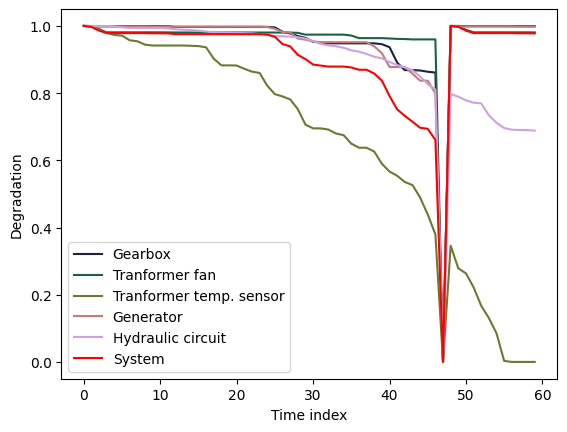

In [ ]:
labels2= {'Gearbox_Damage': 'Gearbox',
 'Transformer_Fan_Damage': 'Tranformer fan',
 'Transformer_Temp_Sensor':'Tranformer temp. sensor',
 'Hydrau_Circuit_Error': 'Hydraulic circuit',
 'Generator_Fail':'Generator'}

sns.set_palette("cubehelix")
for i, (key, values) in enumerate(rull1.items()):
    plt.plot(values, label=f'{labels2[key]}', color=sns.color_palette("cubehelix")[i])
plt.plot(cull1, label='System', color='red' )
plt.xlabel('Time index')
plt.ylabel('Degradation')
plt.legend()
plt.savefig('cul1.pdf', bbox_inches='tight')
plt.show()

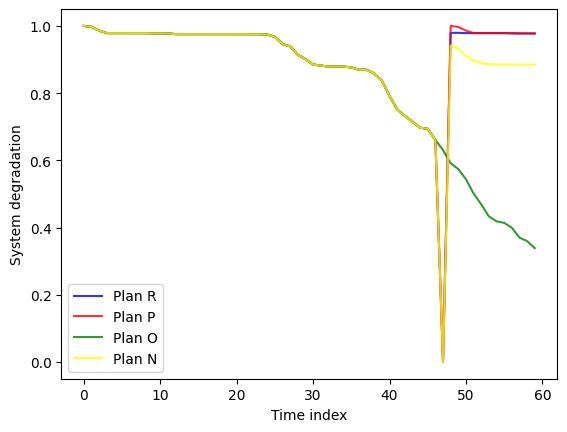

In [ ]:
time = np.arange(60)
plt.plot(time, cull4, label='Plan R', color='blue',  alpha=0.8)
plt.plot(time, cull1, label='Plan P', color='red', alpha=0.8)
plt.plot(time, cull2, label='Plan O', color='green', alpha=0.8)
plt.plot(time, cull3, label='Plan N', color='yellow',  alpha=0.8)

plt.xlabel('Time index')
plt.ylabel('System degradation')
plt.legend()
plt.savefig('cu.pdf', bbox_inches='tight')
plt.show()

# **8.3 O&m based on DE**

# Expr2-based on optimal conditions

In [ ]:
#OM based on optimal predictions
expr_rep2= rep(10, 320, 0.1, 60, 'optimal')

Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.


In [ ]:
expr_rep2.to_csv('/content/drive/MyDrive/j2/expr_rep2.csv')

In [ ]:
sel2=turn(expr_rep2)
sel2.to_csv('/content/drive/MyDrive/j2/SEL2.csv')
print(sel2)
sel2.describe()

  Pop_Size  Std_Dev  Best_Reward                Best_Action  Execution_Time  \
0      320      0.1    50826.285  [0.0, 0.0, 0.0, 0.0, 0.0]         105.433   
1      320      0.1    50826.285  [0.0, 0.0, 0.0, 0.0, 0.0]         114.794   
2      320      0.1    50826.285  [0.0, 0.0, 0.0, 0.0, 0.0]         105.573   
3      320      0.1    50826.285  [0.0, 0.0, 0.0, 0.0, 0.0]         106.198   
4      320      0.1    50826.285  [0.0, 0.0, 0.0, 0.0, 0.0]         105.991   
5      320      0.1    50826.285  [0.0, 0.0, 0.0, 0.0, 0.0]         106.179   
6      320      0.1    50826.285  [0.0, 0.0, 0.0, 0.0, 0.0]         106.435   
7      320      0.1    50826.285  [0.0, 0.0, 0.0, 0.0, 0.0]         105.479   
8      320      0.1    50826.285  [0.0, 0.0, 0.0, 0.0, 0.0]         108.769   
9      320      0.1    50826.285  [0.0, 0.0, 0.0, 0.0, 0.0]         106.006   

   Best_Date  
0          1  
1          1  
2          2  
3         11  
4         11  
5          1  
6          9  
7         

,Std_Dev,Best_Reward,Execution_Time,Best_Date
count,10.0,1.000000e+01,10.000000,10.000000
mean,0.1,5.082629e+04,107.085700,5.400000
std,0.0,7.669533e-12,2.872285,4.526465
min,0.1,5.082629e+04,105.433000,1.000000
25%,0.1,5.082629e+04,105.677500,1.250000
50%,0.1,5.082629e+04,106.092500,3.500000
75%,0.1,5.082629e+04,106.375750,10.500000
max,0.1,5.082629e+04,114.794000,11.000000


# Expr3-based on neutral conditions

In [ ]:
#OM based on neutral predictions
expr_rep3= rep(10, 320, 0.1, 60, 'neutral')

Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.


In [ ]:
expr_rep3

,Pop_Size,Std_Dev,Best_Reward,Best_Action,Reward_List,Execution_Time
0,320,0.1,46750.578934,"[2.2280131188727585, 0.13255185242097733, 0.02...","[40189.683067410406, 43059.45713791219, 43059....",256.202651
1,320,0.1,46750.513504,"[2.0612075038998574, 0.13255184321388475, 0.02...","[41729.927878687944, 43368.282107064064, 43368...",269.436631
2,320,0.1,46750.370229,"[2.5120118040316903, 0.13255184989016913, 0.02...","[42506.13591865179, 43059.45713791219, 43059.4...",253.629441
3,320,0.1,46750.625413,"[2.0728603924292877, 0.1325518306132987, 0.022...","[40179.826901834, 41320.637301276074, 42453.93...",365.684185
4,320,0.1,46750.512206,"[2.6472219024008097, 0.1325518258581677, 0.022...","[39293.32372704754, 43497.38463798492, 44122.0...",245.784004
5,320,0.1,46750.565392,"[2.8134849152929697, 0.13255182616097808, 0.02...","[45407.813023786715, 45407.813023786715, 45407...",289.514972
6,320,0.1,46750.240004,"[2.45992783776744, 0.13255184630105712, 0.0229...","[37019.47551313429, 43059.45713791219, 44818.5...",287.080268
7,320,0.1,46750.222636,"[2.871707213422667, 0.13255183669395582, 0.022...","[39087.02390468608, 43111.80339809295, 43111.8...",236.672154
8,320,0.1,46750.310219,"[2.8368821318082302, 0.13255182261054949, 0.02...","[40326.88094860769, 40909.1781231998, 42222.31...",377.762664
9,320,0.1,46750.155283,"[2.2047791717924774, 0.13255183549488356, 0.02...","[39911.05805760323, 43581.518325119745, 43581....",238.576531


In [ ]:
expr_rep3.to_csv('/content/drive/MyDrive/j2/expr_rep3.csv')

In [ ]:
sel3=turn(expr_rep3)
sel3.to_csv('/content/drive/MyDrive/j2/SEL3.csv')
print(sel3)
sel3.describe()

  Pop_Size  Std_Dev  Best_Reward  \
0      320      0.1    46750.579   
1      320      0.1    46750.514   
2      320      0.1    46750.370   
3      320      0.1    46750.625   
4      320      0.1    46750.512   
5      320      0.1    46750.565   
6      320      0.1    46750.240   
7      320      0.1    46750.223   
8      320      0.1    46750.310   
9      320      0.1    46750.155   

                                         Best_Action  Execution_Time  \
0    [0.1325519, 0.0229783, 7e-07, 0.2089718, 1e-07]         256.203   
1    [0.1325518, 0.0229783, 0.0, 0.2089718, 1.9e-06]         269.437   
2  [0.1325518, 0.0229784, 2e-07, 0.2089718, 2.7e-06]         253.629   
3  [0.1325518, 0.0229783, 1e-07, 0.2089718, 2.6e-06]         365.684   
4  [0.1325518, 0.0229783, 1e-06, 0.2089718, 3.1e-06]         245.784   
5  [0.1325518, 0.0229783, 3.2e-06, 0.2089718, 4e-07]         289.515   
6      [0.1325518, 0.0229783, 0.0, 0.2089718, 8e-07]         287.080   
7    [0.1325518, 0.0229784,

,Std_Dev,Best_Reward,Execution_Time,Best_Date
count,10.0,10.000000,10.000000,10.0
mean,0.1,46750.409300,282.034400,2.0
std,0.0,0.170137,50.701572,0.0
min,0.1,46750.155000,236.672000,2.0
25%,0.1,46750.257500,247.745250,2.0
50%,0.1,46750.441000,262.820000,2.0
75%,0.1,46750.552250,288.906250,2.0
max,0.1,46750.625000,377.763000,2.0


In [ ]:
sel3.describe()

,Std_Dev,Best_Reward,Execution_Time,Best_Date
count,10.0,10.000000,10.000000,10.0
mean,0.1,46750.409300,282.034400,2.0
std,0.0,0.170137,50.701572,0.0
min,0.1,46750.155000,236.672000,2.0
25%,0.1,46750.257500,247.745250,2.0
50%,0.1,46750.441000,262.820000,2.0
75%,0.1,46750.552250,288.906250,2.0
max,0.1,46750.625000,377.763000,2.0


In [ ]:
#on neutral scenario
action3=bestac(expr_rep3)
print(action3)
evaluteSingle(action3, 'pessimistic')
evaluteSingle(action3, 'optimal')
evaluteSingle(action3, 'neutral')
evaluteSingle(action3, 'real')

[2.07286039e+00 1.32551831e-01 2.29783464e-02 5.36683680e-08
 2.08971811e-01 2.61198098e-06]
17578.25205895713
46909.40718624993
46750.638313989424
41771.21362185554


# Expr4-based on real conditions

In [ ]:
expr_rep4= rep(10, 320, 0.1, 60, 'real')

Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.


In [ ]:
expr_rep4.to_csv('/content/drive/MyDrive/j2/expr_rep4.csv')

In [ ]:
sel4=turn(expr_rep4)
sel4.to_csv('/content/drive/MyDrive/j2/SEL4.csv')
print(sel4)
sel4.describe()

  Pop_Size  Std_Dev  Best_Reward  \
0      320      0.1    46245.514   
1      320      0.1    46245.213   
2      320      0.1    46245.165   
3      320      0.1    46245.386   
4      320      0.1    46245.390   
5      320      0.1    46245.512   
6      320      0.1    46245.106   
7      320      0.1    46245.381   
8      320      0.1    46245.224   
9      320      0.1    46245.107   

                                         Best_Action  Execution_Time  \
0      [0.1531282, 0.0210711, 0.0, 0.2230891, 1e-07]         275.357   
1    [0.1531282, 0.0210711, 1e-07, 0.2230891, 2e-07]         242.503   
2        [0.1531282, 0.0210711, 0.0, 0.2230891, 0.0]         220.180   
3    [0.1531282, 0.0210711, 1e-07, 0.2230891, 5e-07]         228.349   
4  [0.1531282, 0.0210711, 1.3e-06, 0.2230891, 1.5...         238.464   
5    [0.1531282, 0.0210711, 0.0, 0.2230891, 2.5e-06]         281.726   
6  [0.1531282, 0.0210711, 3e-07, 0.2230891, 2.4e-06]         235.904   
7  [0.1531282, 0.0210711, 4

 /usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


,Std_Dev,Best_Reward,Execution_Time,Best_Date
count,10.0,10.000000,10.000000,10.0
mean,0.1,46245.299800,243.567600,2.0
std,0.0,0.156081,19.684001,0.0
min,0.1,46245.106000,220.180000,2.0
25%,0.1,46245.177000,234.258000,2.0
50%,0.1,46245.302500,237.184000,2.0
75%,0.1,46245.389000,243.316000,2.0
max,0.1,46245.514000,281.726000,2.0


In [ ]:
#on real scenario
action4=bestac(expr_rep4)
print(action4)
evaluteSingle(action4, 'pessimistic')
evaluteSingle(action4, 'optimal')
evaluteSingle(action4, 'neutral')
evaluteSingle(action4, 'real')

[2.03032196e+00 1.53128185e-01 2.10710762e-02 7.42715536e-09
 2.23089087e-01 5.22171657e-08]
18163.39867187151
46467.87968124612
45618.87710925921
46245.55591392018


# Expr1-based on pessimistic conditions

In [ ]:
expr_rep= rep(10, 320, 0.1, 60, 'pessimistic')

Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.


In [ ]:
expr_rep

,Pop_Size,Std_Dev,Best_Reward,Best_Action,Reward_List,Execution_Time
0,320,0.1,42719.515021,"[2.8490973025604354, 0.24346015600787346, 0.04...","[41687.69476799471, 41687.69476799471, 41687.6...",227.313515
1,320,0.1,42719.338364,"[2.9862446239798315, 0.2434601731870782, 0.049...","[39054.24498019315, 41493.275061843175, 41697....",270.723361
2,320,0.1,42719.285836,"[2.9865105548993673, 0.2434601604020684, 0.049...","[39399.38290606176, 39399.38290606176, 39399.3...",178.355490
3,320,0.1,42718.803996,"[2.997695629450572, 0.2434608856453327, 0.0492...","[35961.08041348028, 38011.654924322065, 38424....",214.520879
4,320,0.1,42719.337125,"[2.9938571581204547, 0.24346018423587906, 0.04...","[40062.777992205345, 40062.777992205345, 40062...",214.088978
5,320,0.1,42719.275718,"[2.9969802188173067, 0.2434601792690317, 0.049...","[36508.59418802666, 36508.59418802666, 37633.2...",209.443078
6,320,0.1,42719.379456,"[2.7270958475114795, 0.24346016467963744, 0.04...","[38627.36922218361, 38816.047750188794, 39091....",208.610452
7,320,0.1,42719.485904,"[2.5754052426914007, 0.24346015693811768, 0.04...","[40917.88624173474, 40917.88624173474, 40917.8...",241.231690
8,320,0.1,42719.083962,"[2.0121574036094625, 0.24346015686449063, 0.04...","[34848.75622187596, 34848.75622187596, 37968.2...",218.120351
9,320,0.1,42719.444953,"[2.3339985905240357, 0.24346015624804232, 0.04...","[37211.26911551836, 40259.973857871104, 40259....",209.805995


In [ ]:
expr_rep.to_csv('/content/drive/MyDrive/j2/expr_rep.csv')

In [ ]:
#on negative scenario
action1=bestac(expr_rep)
print(action1)
evaluteSingle(action1, 'pessimistic')
evaluteSingle(action1, 'optimal')
evaluteSingle(action1, 'neutral')
evaluteSingle(action1, 'real')

[2.84909730e+00 2.43460156e-01 4.92421539e-02 6.66105051e-07
 2.88693072e-01 2.24558973e-07]


43540.29370785287

In [ ]:
sel=turn(expr_rep)
sel.to_csv('/content/drive/MyDrive/j2/SEL.csv')
print(sel)
sel.describe()

  Pop_Size  Std_Dev  Best_Reward  \
0      320      0.1    42719.515   
1      320      0.1    42719.338   
2      320      0.1    42719.286   
3      320      0.1    42718.804   
4      320      0.1    42719.337   
5      320      0.1    42719.276   
6      320      0.1    42719.379   
7      320      0.1    42719.486   
8      320      0.1    42719.084   
9      320      0.1    42719.445   

                                         Best_Action  Execution_Time  \
0    [0.2434602, 0.0492422, 7e-07, 0.2886931, 2e-07]         227.314   
1  [0.2434602, 0.0492422, 2e-07, 0.2886931, 3.8e-06]         270.723   
2  [0.2434602, 0.0492422, 1e-07, 0.2886931, 1.95e...         178.355   
3  [0.2434609, 0.0492423, 0.0002939, 0.2886934, 0...         214.521   
4  [0.2434602, 0.0492422, 8e-07, 0.2886931, 1.4e-06]         214.089   
5    [0.2434602, 0.0492422, 7e-07, 0.2886931, 8e-07]         209.443   
6    [0.2434602, 0.0492422, 1e-07, 0.2886931, 3e-07]         208.610   
7    [0.2434602, 0.0492422,

,Std_Dev,Best_Reward,Execution_Time,Best_Date
count,10.0,10.000000,10.00000,10.0
mean,0.1,42719.295000,219.22130,2.0
std,0.0,0.211895,24.08077,0.0
min,0.1,42718.804000,178.35500,2.0
25%,0.1,42719.278500,209.53375,2.0
50%,0.1,42719.337500,214.30500,2.0
75%,0.1,42719.428500,225.01550,2.0
max,0.1,42719.515000,270.72300,2.0


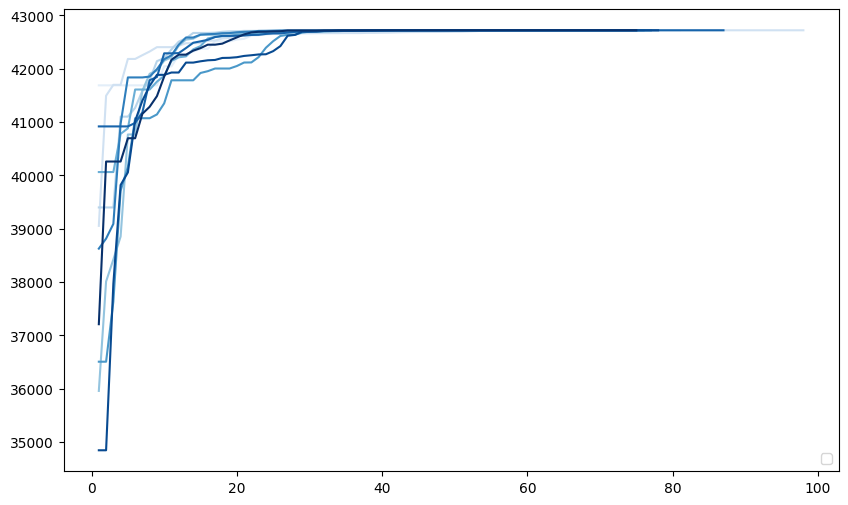

In [ ]:
#pessimistic
plotexp(expr_rep, 'roge.pdf')

In [ ]:
with open('/content/drive/MyDrive/j2/actions.txt', 'w') as file:
    file.write('action1\n')
    file.write(','.join(map(str, action1)) + '\n\n')

    file.write('action3\n')
    file.write(','.join(map(str, action3)) + '\n\n')

    file.write('action4\n')
    file.write(','.join(map(str, action4)) + '\n\n')

print("Actions saved to 'actions.txt'")

Actions saved to 'actions.txt'


# Sensitivity of params on pessimistic predictions

In [ ]:
#different locations
expr_loc = pd.DataFrame(columns=['Std_Dev', 'Best_Reward', 'Reward_List', 'Execution_Time'])
std_dev_values = [0.1, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 2, 2.25, 2.5]

for std_dev in std_dev_values:
    start_time = time.time()
    attitude = "pessimistic"
    env.prereset(attitude)
    env.total_days=60
    best_action, best_reward, reward_list = evolve_population_parallel(population_size=80, num_generations=200, environment=env, timesteps=env.total_days, std_dev=std_dev, condition=False)

    end_time = time.time()
    execution_time = end_time - start_time
    expr_loc  = pd.concat([expr_loc , pd.DataFrame({'Pop_Size': [80], 'Std_Dev': [std_dev], 'Best_Reward': [best_reward], 'Best_Action': [best_action], 'Reward_List': [reward_list], 'Execution_Time': [execution_time]})], ignore_index=True)

 /usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.


In [ ]:
expr_loc

,Std_Dev,Best_Reward,Reward_List,Execution_Time,Pop_Size,Best_Action
0,0.10,42654.684971,"[36096.225018109704, 36907.36208059574, 36907....",159.858881,80.0,"[2.0000009002030987, 0.24346016237106757, 0.04..."
1,0.25,42718.939491,"[33025.05003368398, 33534.81599062657, 34873.6...",204.396619,80.0,"[2.002150721290673, 0.2434601762317778, 0.0492..."
2,0.50,42220.228699,"[29691.56974695997, 29691.56974695997, 30333.5...",161.431931,80.0,"[2.000000108193307, 0.24346015924853365, 0.049..."
3,0.75,40488.001989,"[31499.390497502493, 35563.109529703695, 38505...",213.333090,80.0,"[1.0, 0.20012566891938063, 0.03945129189548817..."
4,1.00,42621.864799,"[38315.24658830202, 39225.78294418454, 39225.7...",190.496854,80.0,"[2.9999970858493596, 0.24346120530006365, 0.04..."
5,1.25,42718.621088,"[32179.151777627085, 32179.151777627085, 33315...",219.766012,80.0,"[2.0004009932379527, 0.24346015689879416, 0.04..."
6,1.50,41423.750995,"[39503.37654417369, 39503.37654417369, 39503.3...",73.439785,80.0,"[2.0, 0.24347486123866477, 0.0852288406633935,..."
7,2.00,42579.785509,"[37878.05752725845, 37878.05752725845, 38820.8...",202.576943,80.0,"[2.0641319002904144, 0.2434601679011606, 0.054..."
8,2.25,42582.380952,"[38254.60995264436, 38254.60995264436, 38254.6...",182.686983,80.0,"[2.028603519003373, 0.24346055387987783, 0.049..."
9,2.50,42599.371643,"[33074.1478187535, 33074.1478187535, 33074.147...",150.402668,80.0,"[2.283394165809423, 0.24346015594018058, 0.050..."


In [ ]:
#params of loc
expr_loc.to_csv('/content/drive/MyDrive/j2/expr_loc.csv')

In [ ]:
#different population size
def run_experiment(pop_size, num_gens, env, timesteps, std_dev, condition):
    start_time = time.time()
    attitude = "pessimistic"
    env.prereset(attitude)
    env.total_days=timesteps
    # Run the optimization algorithm with the specified population size
    best_action, best_reward, reward_list = evolve_population_parallel(population_size=pop_size, num_generations=num_gens, environment=env, timesteps=timesteps, std_dev=std_dev, condition=condition)
    end_time = time.time()
    exec_time = end_time - start_time

    return {'Pop_Size': pop_size,
        'Std_Dev': 0.1,
        'Best_Action': best_action,
        'Best_Reward': best_reward,
        'Reward_List': reward_list,
        'Execution_Time': exec_time}

def pop_size_experiment(pop_sizes, num_gens, env, timesteps, std_dev, condition):
    results_list = []

    for size in pop_sizes:
        result = run_experiment(size, num_gens, env, timesteps, std_dev, condition)
        results_list.append(result)

    df_results = pd.DataFrame(results_list)
    return df_results

In [ ]:
pop_sizes_to_try = [32, 40, 80, 160, 240, 320, 400, 480, 560, 640]  # Add more sizes as needed
expr_size = pop_size_experiment(pop_sizes_to_try, num_gens=200, env=env, timesteps=60, std_dev=0.1, condition=False)

Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.


In [ ]:
pop_sizes_to_try2 = [720,800,880, 960, 1040]  # Add more sizes as needed
expr_size2 = pop_size_experiment(pop_sizes_to_try2, num_gens=200, env=env, timesteps=60, std_dev=0.1, condition=False)

 /usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.
Early stopping after 30 generations with no improvement.


In [ ]:
expr_size2.to_csv('/content/drive/MyDrive/j2/expr_size2.csv')
expr_size2

,Pop_Size,Std_Dev,Best_Action,Best_Reward,Reward_List,Execution_Time
0,720,0.1,"[2.305286902957396, 0.24346016880767554, 0.049...",42719.095751,"[40575.28579997225, 40575.28579997225, 40575.2...",417.852058
1,800,0.1,"[2.148769834538174, 0.24346015787973121, 0.049...",42719.441576,"[39020.35793347751, 39020.35793347751, 40733.2...",463.801476
2,880,0.1,"[2.2841912441095236, 0.24346017466871805, 0.04...",42719.434787,"[36991.82827588097, 38565.080834620036, 38983....",503.972783
3,960,0.1,"[2.8965228355849812, 0.24346018907755015, 0.04...",42719.407101,"[41545.92631586812, 41545.92631586812, 41545.9...",520.042094
4,1040,0.1,"[2.380501372720449, 0.2434601741378609, 0.0492...",42719.417747,"[40411.51706019636, 40517.44118011763, 40927.5...",579.217628


In [ ]:
expr_size3=pd.concat([expr_size2, expr_size])

In [ ]:
expr_size.to_csv('/content/drive/MyDrive/j2/expr_size.csv')
expr_size

,Pop_Size,Std_Dev,Best_Action,Best_Reward,Reward_List,Execution_Time
0,32,0.1,"[1.0, 0.2001257003484715, 0.03945127333294935,...",39791.976698,"[29303.38234377766, 30714.565260959844, 35563....",69.149201
1,40,0.1,"[2.0466339772235593, 0.24346045464091917, 0.05...",41923.318317,"[34802.48082339381, 34802.48082339381, 34802.4...",70.420061
2,80,0.1,"[2.0198013331510323, 0.2434601778841698, 0.049...",42719.248587,"[33987.886681834774, 36341.42302122164, 37206....",188.362967
3,160,0.1,"[2.1243991687120305, 0.24346015620695682, 0.04...",42719.345358,"[37512.93612230618, 37565.68487763708, 38465.9...",241.163417
4,240,0.1,"[2.9976257587360333, 0.2434601569433797, 0.049...",42719.339849,"[33351.192237305935, 36539.70292240553, 36730....",226.551463
5,320,0.1,"[2.8955962782255855, 0.24346015698865522, 0.04...",42719.505349,"[37537.73616561609, 38533.78510910338, 40256.9...",270.865858
6,400,0.1,"[2.729049954635016, 0.24346016768405007, 0.049...",42719.388341,"[37987.27942315367, 37987.27942315367, 38477.9...",263.929524
7,480,0.1,"[2.999865776752491, 0.24259215068983214, 0.049...",42708.823410,"[40796.52735851049, 40796.52735851049, 40796.5...",481.278861
8,560,0.1,"[2.1691114143906174, 0.2434601583709056, 0.049...",42719.424200,"[38786.15316113369, 38786.15316113369, 38786.1...",337.491380
9,640,0.1,"[2.8171366134797844, 0.24346016545224386, 0.04...",42719.210366,"[38267.86696534448, 38683.15804683183, 41702.5...",393.469854


In [ ]:
#the sum of all reults *original
#important
experiment= pd.concat([expr_loc, expr_size, expr_size2])
experiment.to_csv('/content/drive/MyDrive/j2/expr_sizeloc.csv')

In [ ]:
experiment= pd.concat([expr_loc, expr_size, expr_size2])
experiment['Best_Action'] = experiment['Best_Action'].apply(lambda x: [round(x[0])] + [round(elem, 3) for elem in x[1:]]).astype('object')
experiment['Best_Date'] = experiment['Best_Action'].apply(lambda x:x[0])
experiment

,Std_Dev,Best_Reward,Reward_List,Execution_Time,Pop_Size,Best_Action,Best_Date
0,0.10,42654.684971,"[36096.225018109704, 36907.36208059574, 36907....",159.858881,80.0,"[2, 0.243, 0.049, 0.0, 0.289, 0.645]",2
1,0.25,42718.939491,"[33025.05003368398, 33534.81599062657, 34873.6...",204.396619,80.0,"[2, 0.243, 0.049, 0.0, 0.289, 0.003]",2
2,0.50,42220.228699,"[29691.56974695997, 29691.56974695997, 30333.5...",161.431931,80.0,"[2, 0.243, 0.049, 0.604, 0.289, 0.764]",2
3,0.75,40488.001989,"[31499.390497502493, 35563.109529703695, 38505...",213.333090,80.0,"[1, 0.2, 0.039, 0.0, 0.246, 0.0]",1
4,1.00,42621.864799,"[38315.24658830202, 39225.78294418454, 39225.7...",190.496854,80.0,"[3, 0.243, 0.049, 0.083, 0.289, 0.392]",3
5,1.25,42718.621088,"[32179.151777627085, 32179.151777627085, 33315...",219.766012,80.0,"[2, 0.243, 0.049, 0.0, 0.289, 0.0]",2
6,1.50,41423.750995,"[39503.37654417369, 39503.37654417369, 39503.3...",73.439785,80.0,"[2, 0.243, 0.085, 0.746, 0.289, 0.737]",2
7,2.00,42579.785509,"[37878.05752725845, 37878.05752725845, 38820.8...",202.576943,80.0,"[2, 0.243, 0.055, 0.0, 0.289, 0.0]",2
8,2.25,42582.380952,"[38254.60995264436, 38254.60995264436, 38254.6...",182.686983,80.0,"[2, 0.243, 0.049, 0.088, 0.289, 0.757]",2
9,2.50,42599.371643,"[33074.1478187535, 33074.1478187535, 33074.147...",150.402668,80.0,"[2, 0.243, 0.05, 0.008, 0.289, 0.79]",2


In [ ]:
sel = experiment.iloc[:, [0, 1, 3, 4, 5, 6]].round(3)
sel['Best_Action']=sel['Best_Action'].apply(lambda x: x[1:]).astype('object')
sel

,Std_Dev,Best_Reward,Execution_Time,Pop_Size,Best_Action,Best_Date
0,0.10,42654.685,159.859,80.0,"[0.243, 0.049, 0.0, 0.289, 0.645]",2
1,0.25,42718.939,204.397,80.0,"[0.243, 0.049, 0.0, 0.289, 0.003]",2
2,0.50,42220.229,161.432,80.0,"[0.243, 0.049, 0.604, 0.289, 0.764]",2
3,0.75,40488.002,213.333,80.0,"[0.2, 0.039, 0.0, 0.246, 0.0]",1
4,1.00,42621.865,190.497,80.0,"[0.243, 0.049, 0.083, 0.289, 0.392]",3
5,1.25,42718.621,219.766,80.0,"[0.243, 0.049, 0.0, 0.289, 0.0]",2
6,1.50,41423.751,73.440,80.0,"[0.243, 0.085, 0.746, 0.289, 0.737]",2
7,2.00,42579.786,202.577,80.0,"[0.243, 0.055, 0.0, 0.289, 0.0]",2
8,2.25,42582.381,182.687,80.0,"[0.243, 0.049, 0.088, 0.289, 0.757]",2
9,2.50,42599.372,150.403,80.0,"[0.243, 0.05, 0.008, 0.289, 0.79]",2


In [ ]:
#the sum of all experiment.  Rounded list
#important
sel.to_csv("/content/drive/MyDrive/j2/expr_sel.csv")

# Plot rewards over generations

In [ ]:
from ast import literal_eval
experiment=pd.read_csv('/content/drive/MyDrive/j2/expr_sizeloc.csv', index_col=0)
experiment["Reward_List"] = experiment["Reward_List"].apply(literal_eval)
experiment

,Std_Dev,Best_Reward,Reward_List,Execution_Time,Pop_Size,Best_Action
0,0.10,42654.684971,"[36096.225018109704, 36907.36208059574, 36907....",159.858881,80.0,[2.00000090e+00 2.43460162e-01 4.92571316e-02 ...
1,0.25,42718.939491,"[33025.05003368398, 33534.81599062657, 34873.6...",204.396619,80.0,[2.00215072e+00 2.43460176e-01 4.92421658e-02 ...
2,0.50,42220.228699,"[29691.56974695997, 29691.56974695997, 30333.5...",161.431931,80.0,[2.00000011 0.24346016 0.04924219 0.60425883 0...
3,0.75,40488.001989,"[31499.390497502493, 35563.109529703695, 38505...",213.333090,80.0,[1.00000000e+00 2.00125669e-01 3.94512919e-02 ...
4,1.00,42621.864799,"[38315.24658830202, 39225.78294418454, 39225.7...",190.496854,80.0,[2.99999709 0.24346121 0.04924216 0.08343758 0...
5,1.25,42718.621088,"[32179.151777627085, 32179.151777627085, 33315...",219.766012,80.0,[2.00040099e+00 2.43460157e-01 4.92590226e-02 ...
6,1.50,41423.750995,"[39503.37654417369, 39503.37654417369, 39503.3...",73.439785,80.0,[2. 0.24347486 0.08522884 0.74603296 0...
7,2.00,42579.785509,"[37878.05752725845, 37878.05752725845, 38820.8...",202.576943,80.0,[2.06413190e+00 2.43460168e-01 5.49406190e-02 ...
8,2.25,42582.380952,"[38254.60995264436, 38254.60995264436, 38254.6...",182.686983,80.0,[2.02860352 0.24346055 0.04924233 0.08761735 0...
9,2.50,42599.371643,"[33074.1478187535, 33074.1478187535, 33074.147...",150.402668,80.0,[2.28339417 0.24346016 0.05031586 0.00823718 0...


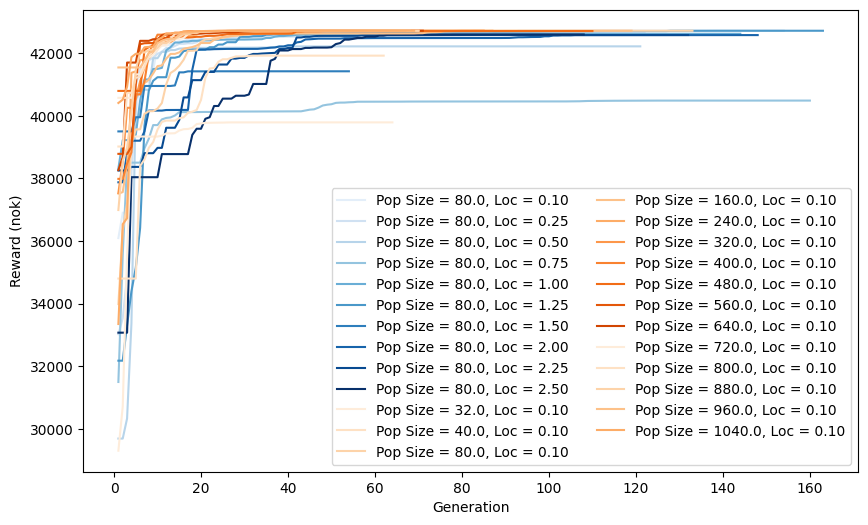

In [ ]:
#plot of sensitivity towards different parameter combination
expr1=experiment
plt.figure(figsize=(10, 6))

cmap_blue = plt.cm.Blues
for i, row in expr1.head(10).iterrows():
    gen_length = list(range(1, len(row['Reward_List']) + 1))
    color = cmap_blue((i + 1) / 10)
    label_text = f'Pop Size = {row["Pop_Size"]}, Loc = {row["Std_Dev"]:.2f}'
    plt.plot(gen_length, list(row['Reward_List']), label=label_text, color=color)


cmap_green = plt.cm.Oranges
for i, row in expr1.tail(15).iterrows():
    gen_length = list(range(1, len(row['Reward_List']) + 1))
    color = cmap_green((i + 1) / 13)
    label_text = f'Pop Size = {row["Pop_Size"]}, Loc = {row["Std_Dev"]:.2f}'
    plt.plot(gen_length, list(row['Reward_List']), label=label_text, color=color)
plt.xlabel('Generation')
plt.ylabel('Reward (nok)')

plt.legend(loc='lower right',  ncol=2)
plt.savefig('roge2.pdf',bbox_inches='tight')
plt.show()